In [ ]:
#### بسم الله الرحمن تالرحیم

In [1]:
import os
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import torchcrepe
import librosa
from transformers import (
    WavLMModel,
    HubertModel,
    Wav2Vec2Model,
    Data2VecAudioModel,
    WhisperModel, WhisperFeatureExtractor
)

# ---------------------------------------------------------
# ۱. تنظیمات و مسیرها
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--> Using compute device: {device}")

MODELS_DIR = "./pretrained_models"
FILELIST_PATH = "./filelists/probing_hard/VCTK_100spk_20utt_test.txt"
# اگر در فایل تست فقط مسیر نسبی هست، مسیر ریشه wavها را مشخص کنید (در صورت نیاز تغییر دهید):
AUDIO_ROOT = "./" 

# 

#خواندن لیست فایل‌های ارزیابی
valid_audio_files = []
if os.path.exists(FILELIST_PATH):
    with open(FILELIST_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # فرض بر این است که هر خط یا مسیر کامل فایل است یا مسیر با سپراتور تب/اسپیس
            parts = line.split()
            wav_rel_path = parts[0]
            full_path = os.path.join(AUDIO_ROOT, wav_rel_path) if not os.path.isabs(wav_rel_path) else wav_rel_path
            
            if os.path.exists(full_path):
                valid_audio_files.append(full_path)
            elif os.path.exists(wav_rel_path):
                valid_audio_files.append(wav_rel_path)

# اگر نیاز به لیمیت تعداد برای ارزیابی سریع دارید (مثلا 50 تا 100 نمونه اول):
MAX_EVAL_SAMPLES = 50
valid_audio_files = valid_audio_files[:MAX_EVAL_SAMPLES]

if not valid_audio_files:
    raise FileNotFoundError(f"هیچ فایل معتبری از لیست {FILELIST_PATH} یافت نشد. لطفاً مسیر فایل‌ها را بررسی کنید.")

print(f"--> Loaded {len(valid_audio_files)} test audio samples for comprehensive prosody probing.")



/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--> Using compute device: cuda
--> Loaded 50 test audio samples for comprehensive prosody probing.


In [2]:
# ==========================================
# 2. لود یک‌باره مدل‌ها در حافظه (Pre-loading)
# ==========================================
model_configs = {
    "WavLM-Base+": "wavlm-base-plus",
    "HuBERT-Base": "hubert-base",
    "Wav2Vec2-Base": "wav2vec2-base",
    "Data2Vec-Audio": "data2vec-audio-base-960h",
    "Whisper-Small (Enc)": "whisper-small"
}

loaded_models = {}
loaded_extractors = {}

print("\n--> Pre-loading all 5 models into memory...")
for model_name, folder_name in model_configs.items():
    path = os.path.join(MODELS_DIR, folder_name)
    print(f"   Loading {model_name}...")
    
    if model_name == "Whisper-Small (Enc)":
        loaded_extractors[model_name] = WhisperFeatureExtractor.from_pretrained(path)
        m = WhisperModel.from_pretrained(path).to(device)
        m.eval()
        loaded_models[model_name] = m
    else:
        if "data2vec" in folder_name:
            m = Data2VecAudioModel.from_pretrained(path).to(device)
        elif "wavlm" in folder_name:
            m = WavLMModel.from_pretrained(path).to(device)
        elif "hubert" in folder_name:
            m = HubertModel.from_pretrained(path).to(device)
        elif "wav2vec2" in folder_name:
            m = Wav2Vec2Model.from_pretrained(path).to(device)
        
        m.eval()
        loaded_models[model_name] = m

print("--> All 5 models loaded successfully!")



--> Pre-loading all 5 models into memory...
   Loading WavLM-Base+...


Loading weights: 100%|████████████████████████████████████████████████████████████| 248/248 [00:00<00:00, 42128.20it/s]


   Loading HuBERT-Base...


Loading weights: 100%|████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 14719.06it/s]


   Loading Wav2Vec2-Base...


...

   Loading Data2Vec-Audio...


Loading weights: 100%|████████████████████████████████████████████████████████████| 230/230 [00:00<00:00, 24606.30it/s]
[transformers] Data2VecAudioModel LOAD REPORT from: ./pretrained_models/data2vec-audio-base-960h
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Loading Whisper-Small (Enc)...


Loading weights: 100%|████████████████████████████████████████████████████████████| 479/479 [00:00<00:00, 18576.37it/s]


--> All 5 models loaded successfully!


In [1]:
%%writefile MRH_make_probe_filelists.py

import argparse
import csv
import random
import re
from pathlib import Path
from collections import Counter


VCTK_PATTERN = re.compile(
    r"^(?P<speaker>p\d+)_(?P<utterance>\d+)_mic(?P<mic>\d+)\.flac$",
    flags=re.IGNORECASE,
)


def parse_vctk_file(wav_path):
    """
    Parse a VCTK filename such as:
        p260_006_mic1.flac
    """
    match = VCTK_PATTERN.match(wav_path.name)

    if match is None:
        return None

    return {
        "path": str(wav_path.resolve()),
        "speaker": match.group("speaker").lower(),
        "utterance": match.group("utterance"),
        "microphone": int(match.group("mic")),
    }


def write_path_list(output_path, samples):
    """
    Write a FreeVC-style file list containing one absolute path per line.
    No DUMMY prefix is added.
    """
    with output_path.open("w", encoding="utf-8", newline="\n") as file:
        for sample in samples:
            file.write(sample["path"] + "\n")


def write_manifest(output_path, samples):
    """
    Write metadata required by speaker/content probing.
    """
    fieldnames = [
        "path",
        "speaker",
        "utterance",
        "microphone",
        "split",
    ]

    with output_path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames,
            delimiter="\t",
        )
        writer.writeheader()
        writer.writerows(samples)


def main():
    parser = argparse.ArgumentParser(
        description="Create VCTK file lists for layer-wise probing."
    )

    parser.add_argument(
        "--source_dir",
        type=str,
        required=True,
        help="VCTK wav48_silence_trimmed directory",
    )
    parser.add_argument(
        "--output_dir",
        type=str,
        default="./filelists/probing",
        help="Directory used to save output file lists",
    )
    parser.add_argument(
        "--prefix",
        type=str,
        default="VCTK_probe",
        help="Output filename prefix",
    )
    parser.add_argument(
        "--microphone",
        type=int,
        default=1,
        help="VCTK microphone number to include; mic1 is recommended",
    )
    parser.add_argument(
        "--val_per_speaker",
        type=int,
        default=5,
        help="Number of validation utterances per speaker",
    )
    parser.add_argument(
        "--test_per_speaker",
        type=int,
        default=10,
        help="Number of test utterances per speaker",
    )
    parser.add_argument(
        "--train_ratio",
        type=float,
        default=1.0,
        help="Fraction of remaining utterances used for training",
    )
    parser.add_argument(
        "--max_speakers",
        type=int,
        default=None,
        help="Optional maximum number of speakers",
    )
    parser.add_argument(
        "--max_files_per_speaker",
        type=int,
        default=None,
        help="Optional maximum number of files selected per speaker",
    )
    parser.add_argument(
        "--seed",
        type=int,
        default=42,
        help="Random seed",
    )

    args = parser.parse_args()

    if not 0.0 < args.train_ratio <= 1.0:
        raise ValueError("--train_ratio must be in the interval (0, 1].")

    source_dir = Path(args.source_dir).expanduser()

    if not source_dir.exists():
        raise FileNotFoundError(
            f"Source directory does not exist:\n{source_dir}"
        )

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Scanning VCTK directory:\n{source_dir}")

    speaker_files = {}

    # VCTK silence-trimmed files normally use FLAC.
    for wav_path in sorted(source_dir.rglob("*.flac")):
        
        print ("MRH wav_path= ",wav_path)
        metadata = parse_vctk_file(wav_path)

        if metadata is None:
            continue

        if metadata["microphone"] != args.microphone:
            continue

        speaker = metadata["speaker"]
        speaker_files.setdefault(speaker, []).append(metadata)

    speakers = sorted(speaker_files)

    if args.max_speakers is not None:
        speakers = speakers[:args.max_speakers]

    if not speakers:
        raise RuntimeError(
            "No matching VCTK FLAC files were found. "
            "Check source_dir and microphone selection."
        )

    train_samples = []
    val_samples = []
    test_samples = []
    skipped_speakers = []

    minimum_required = (
        args.val_per_speaker
        + args.test_per_speaker
        + 1
    )

    for speaker_index, speaker in enumerate(speakers):
        print("MRH speaker = ", speaker)
        samples = list(speaker_files[speaker])

        # A separate deterministic RNG is used for every speaker.
        speaker_rng = random.Random(args.seed + speaker_index)
        speaker_rng.shuffle(samples)

        if args.max_files_per_speaker is not None:
            samples = samples[:args.max_files_per_speaker]

        if len(samples) < minimum_required:
            skipped_speakers.append((speaker, len(samples)))
            continue

        val_end = args.val_per_speaker
        test_end = val_end + args.test_per_speaker

        val_part = samples[:val_end]
        test_part = samples[val_end:test_end]
        remaining_train = samples[test_end:]

        number_of_train_samples = max(
            1,
            int(len(remaining_train) * args.train_ratio),
        )
        train_part = remaining_train[:number_of_train_samples]

        for sample in train_part:
            sample["split"] = "train"

        for sample in val_part:
            sample["split"] = "val"

        for sample in test_part:
            sample["split"] = "test"

        train_samples.extend(train_part)
        val_samples.extend(val_part)
        test_samples.extend(test_part)

    # Shuffle global list order without changing split membership.
    global_rng = random.Random(args.seed)
    global_rng.shuffle(train_samples)
    global_rng.shuffle(val_samples)
    global_rng.shuffle(test_samples)

    all_samples = train_samples + val_samples + test_samples

    train_path = output_dir / f"{args.prefix}_train.txt"
    val_path = output_dir / f"{args.prefix}_val.txt"
    test_path = output_dir / f"{args.prefix}_test.txt"
    manifest_path = output_dir / f"{args.prefix}_manifest.tsv"

    write_path_list(train_path, train_samples)
    write_path_list(val_path, val_samples)
    write_path_list(test_path, test_samples)
    write_manifest(manifest_path, all_samples)

    split_counts = Counter(sample["split"] for sample in all_samples)
    included_speakers = sorted(
        {sample["speaker"] for sample in all_samples}
    )

    print("\nDataset statistics")
    print("-" * 55)
    print(f"Included speakers : {len(included_speakers)}")
    print(f"Skipped speakers  : {len(skipped_speakers)}")
    print(f"Train samples     : {split_counts['train']}")
    print(f"Validation samples: {split_counts['val']}")
    print(f"Test samples      : {split_counts['test']}")
    print(f"Total samples     : {len(all_samples)}")
    print(f"Microphone        : mic{args.microphone}")
    print("-" * 55)

    if skipped_speakers:
        print("\nSkipped speakers:")
        for speaker, count in skipped_speakers:
            print(f"  {speaker}: only {count} usable files")

    print("\nGenerated files:")
    print(f"  {train_path.resolve()}")
    print(f"  {val_path.resolve()}")
    print(f"  {test_path.resolve()}")
    print(f"  {manifest_path.resolve()}")

    print("\nFile lists created successfully.")


if __name__ == "__main__":
    main()


Overwriting MRH_make_probe_filelists.py


In [ ]:
!python MRH_make_probe_filelists.py --source_dir "/mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed" --output_dir "./filelists/probing_hard" --prefix "VCTK_100spk_20utt" --microphone 1 --max_speakers 100 --max_files_per_speaker 20 --val_per_speaker 3 --test_per_speaker 5 --train_ratio 1.0 --seed 42

 ### گام ۱: بارگذاری Manifest 

In [12]:
import pandas as pd
from pathlib import Path

MANIFEST_PATH = Path("./filelists/probing_hard/VCTK_100spk_20utt_manifest.tsv")

manifest = pd.read_csv(MANIFEST_PATH, sep="\t")

required_columns = {"path", "speaker", "utterance", "microphone", "split"}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# تصحیح تبدیل نوع داده‌ها
manifest["speaker"] = manifest["speaker"].astype(str)
manifest["utterance"] = manifest["utterance"].astype(str)
manifest["split"] = manifest["split"].astype(str)

print("--- Data Summary ---")
print(manifest.head(5))
print("\nSplit counts:\n", manifest["split"].value_counts())
print("\nUnique speakers:", manifest["speaker"].nunique())

# بررسی معتبر بودن مسیر فایل‌ها
missing_files = sum(not Path(p).exists() for p in manifest["path"])
print(f"Missing audio files count: {missing_files}")


--- Data Summary ---
                                                path speaker utterance  \
0  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_s...    p263        59   
1  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_s...    p301       155   
2  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_s...    p267        57   
3  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_s...    p262       330   
4  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_s...    p295       295   

   microphone  split  
0           1  train  
1           1  train  
2           1  train  
3           1  train  
4           1  train  

Split counts:
 split
train    1200
test      500
val       300
Name: count, dtype: int64

Unique speakers: 100
Missing audio files count: 0


In [21]:
import pandas as pd
from pathlib import Path

# مسیر مانیفست 100 گوینده‌ای جدید
HARD_MANIFEST_PATH = Path("./filelists/probing_hard/VCTK_100spk_20utt_manifest.tsv")

if not HARD_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"فایل مانیفست در مسیر {HARD_MANIFEST_PATH} یافت نشد!")

manifest_hard = pd.read_csv(HARD_MANIFEST_PATH, sep="\t")

manifest_hard["speaker"] = manifest_hard["speaker"].astype(str)
manifest_hard["utterance"] = manifest_hard["utterance"].astype(str)
manifest_hard["split"] = manifest_hard["split"].astype(str)

print("--- Hard Dataset Summary ---")
print(f"Total Audio Samples: {len(manifest_hard)}")
print("\nSplit Distribution:")
print(manifest_hard["split"].value_counts())
print("\nUnique Speakers:", manifest_hard["speaker"].nunique())

# چک کردن موجود بودن تمام فایل‌های صوتی
missing_files = sum(not Path(p).exists() for p in manifest_hard["path"])
print(f"\nMissing Audio Files Count: {missing_files}")


--- Hard Dataset Summary ---
Total Audio Samples: 2000

Split Distribution:
split
train    1200
test      500
val       300
Name: count, dtype: int64

Unique Speakers: 100

Missing Audio Files Count: 0


In [ ]:
۲. تعریف توابع استخراج (با پشتیبانی هم‌زمان از Mean و Mean+Std)¶

In [22]:
import torch
import torchaudio

EMBEDDING_DIR = Path("./probing_outputs/initial_speaker_embeddings")
EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000

def load_audio_for_probe(audio_path, target_sr=TARGET_SR):
    waveform, sample_rate = torchaudio.load(audio_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform

def pool_hidden_states(hidden_state):
    """
    hidden_state: [T, D]
    returns:
      mean_pooled: [D]
      mean_std_pooled: [2D]
    """
    hidden_state = hidden_state.float()
    mean_vec = hidden_state.mean(dim=0)
    std_vec = hidden_state.std(dim=0, unbiased=False)
    
    return {
        "mean": mean_vec,
        "mean_std": torch.cat([mean_vec, std_vec], dim=0)
    }

def extract_layerwise_utterance_embeddings(audio_path):
    audio = load_audio_for_probe(audio_path)
    layerwise_embeddings = {}

    for model_name in loaded_models.keys():
        hidden_states = extract_hidden_states(model_name, audio)
        
        pooled_mean = []
        pooled_mean_std = []
        
        for hs in hidden_states:
            pools = pool_hidden_states(hs)
            pooled_mean.append(pools["mean"].cpu())
            pooled_mean_std.append(pools["mean_std"].cpu())
            
        layerwise_embeddings[model_name] = {
            "mean": pooled_mean,
            "mean_std": pooled_mean_std
        }

    return layerwise_embeddings


In [33]:
# ==========================================
# 3. استخراج ویژگی از مدل‌های بارگذاری‌شده
# ==========================================
def extract_hidden_states(model_key, audio_tensor):
    model = loaded_models[model_key]
    
    with torch.no_grad():
        if model_key == "Whisper-Small (Enc)":
            feature_extractor = loaded_extractors[model_key]
            inputs = feature_extractor(
                audio_tensor.squeeze().numpy(), 
                sampling_rate=16000, 
                return_tensors="pt"
            ).input_features.to(device)
            
            encoder_outputs = model.encoder(inputs, output_hidden_states=True)
            hidden_states = [h.squeeze(0).cpu() for h in encoder_outputs.hidden_states]
        else:
            input_values = audio_tensor.to(device)
            outputs = model(input_values, output_hidden_states=True)
            hidden_states = [h.squeeze(0).cpu() for h in outputs.hidden_states]
            
    return hidden_states


In [ ]:
۳. استخراج و ذخیره‌سازی Embeddingها (اجرا روی ۸۰۰ فایل)

In [30]:
from pathlib import Path
import torch
import torchaudio
from tqdm.auto import tqdm

EMBEDDING_DIR_HARD = Path("./probing_outputs/hard_speaker_embeddings")
EMBEDDING_DIR_HARD.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000

def load_audio_for_probe(audio_path, target_sr=TARGET_SR):
    waveform, sample_rate = torchaudio.load(audio_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform

def pool_hidden_states(hidden_state):
    hidden_state = hidden_state.float()
    mean_vec = hidden_state.mean(dim=0)
    std_vec = hidden_state.std(dim=0, unbiased=False)
    return {
        "mean": mean_vec,
        "mean_std": torch.cat([mean_vec, std_vec], dim=0)
    }

def extract_layerwise_utterance_embeddings(audio_path):
    audio = load_audio_for_probe(audio_path)
    layerwise_embeddings = {}

    for model_name in loaded_models.keys():
        hidden_states = extract_hidden_states(model_name, audio)
        
        pooled_mean = []
        pooled_mean_std = []
        
        for hs in hidden_states:
            pools = pool_hidden_states(hs)
            pooled_mean.append(pools["mean"].cpu())
            pooled_mean_std.append(pools["mean_std"].cpu())
            
        layerwise_embeddings[model_name] = {
            "mean": pooled_mean,
            "mean_std": pooled_mean_std
        }

    return layerwise_embeddings

# استخراج داده‌های مانیفست 100 گوینده‌ای
metadata_records_hard = []

for row_index, row in tqdm(
    manifest_hard.iterrows(),
    total=len(manifest_hard),
    desc="Extracting 100-Speaker Embeddings",
):
    audio_path = row["path"]
    try:
        embeddings = extract_layerwise_utterance_embeddings(audio_path)
        output_file = EMBEDDING_DIR_HARD / f"{row_index:06d}.pt"

        torch.save(
            {
                "path": audio_path,
                "speaker": row["speaker"],
                "utterance": row["utterance"],
                "microphone": int(row["microphone"]),
                "split": row["split"],
                "embeddings": embeddings,
            },
            output_file,
        )

        metadata_records_hard.append(
            {
                "row_index": row_index,
                "embedding_path": str(output_file),
                "path": audio_path,
                "speaker": row["speaker"],
                "utterance": row["utterance"],
                "split": row["split"],
            }
        )
    except Exception as error:
        print(f"\nFailed processing {audio_path}: {error}")

embedding_index_hard = pd.DataFrame(metadata_records_hard)
embedding_index_hard_path = EMBEDDING_DIR_HARD / "embedding_index_hard.tsv"
embedding_index_hard.to_csv(embedding_index_hard_path, sep="\t", index=False)

print(f"\nSuccessfully extracted and saved {len(embedding_index_hard)} embeddings.")


Extracting 100-Speaker Embeddings: 100%|███████████████████████████████████████████| 2000/2000 [06:21<00:00,  5.25it/s]



Successfully extracted and saved 2000 embeddings.


In [ ]:
۴. آموزش Linear Probe (آزمایش پایه: Mean Pooling)

In [37]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

MODEL_NAMES = list(loaded_models.keys())

# انکود کردن شناسه گویندگان (100 کلاس)
speaker_encoder = LabelEncoder()
embedding_index_hard["speaker_id"] = speaker_encoder.fit_transform(embedding_index_hard["speaker"])

train_df = embedding_index_hard[embedding_index_hard["split"] == "train"].reset_index(drop=True)
val_df = embedding_index_hard[embedding_index_hard["split"] == "val"].reset_index(drop=True)
test_df = embedding_index_hard[embedding_index_hard["split"] == "test"].reset_index(drop=True)

def load_matrix(index_df, model_name, layer_index, pool_type="mean"):
    vectors = []
    labels = []
    for _, row in index_df.iterrows():
        item = torch.load(row["embedding_path"], map_location="cpu")
        vec = item["embeddings"][model_name][pool_type][layer_index]
        vectors.append(vec.numpy())
        labels.append(int(row["speaker_id"]))
    return np.stack(vectors), np.asarray(labels)

def train_speaker_probe(model_name, layer_index, pool_type="mean"):
    X_train, y_train = load_matrix(train_df, model_name, layer_index, pool_type)
    X_val, y_val = load_matrix(val_df, model_name, layer_index, pool_type)
    X_test, y_test = load_matrix(test_df, model_name, layer_index, pool_type)

    classifier = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
    ])

    classifier.fit(X_train, y_train)

    val_pred = classifier.predict(X_val)
    test_pred = classifier.predict(X_test)

    return {
        "model": model_name,
        "layer": layer_index,
        "pooling": pool_type,
        "val_acc": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "test_acc": accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro"),
    }

# اجرا روی تمام لایه‌ها
results_hard = []
sample_item = torch.load(train_df.iloc[0]["embedding_path"], map_location="cpu")

for model_name in MODEL_NAMES:
    num_layers = len(sample_item["embeddings"][model_name]["mean"])
    for layer_idx in tqdm(range(num_layers), desc=f"Probing {model_name} (100 Speakers)"):
        res = train_speaker_probe(model_name, layer_idx, pool_type="mean")
        results_hard.append(res)

results_hard_df = pd.DataFrame(results_hard)
results_hard_df.to_csv("./probing_outputs/speaker_layerwise_hard_mean_results.csv", index=False)


Probing Whisper-Small (Enc) (100 Speakers): 100%|██████████████████████████████████████| 13/13 [12:05<00:00, 55.80s/it]


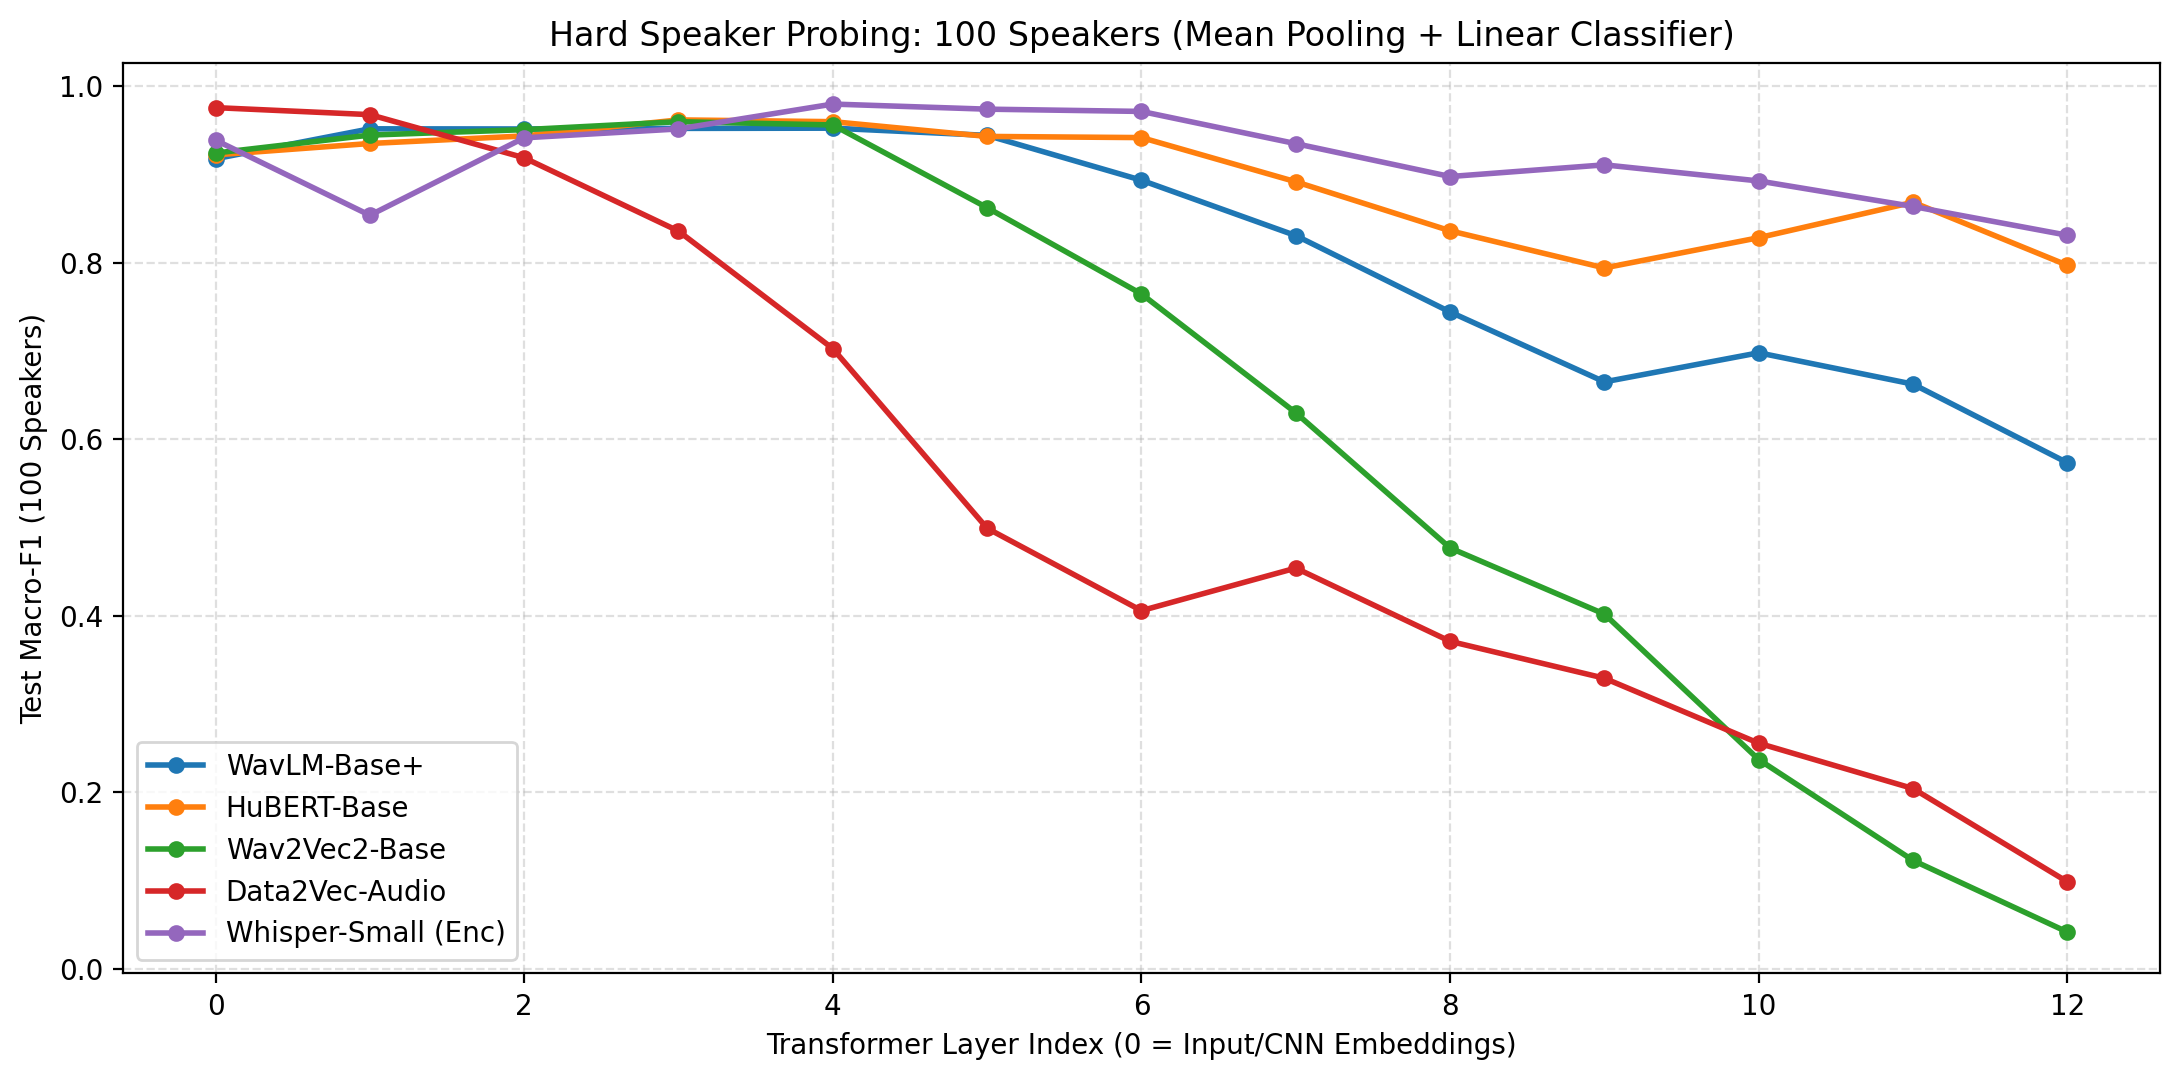


--- Best Speaker Representation Layer Per Model (100 Speakers) ---


,model,layer,val_macro_f1,test_macro_f1,test_acc
0,Data2Vec-Audio,0,0.979786,0.975778,0.976
1,HuBERT-Base,3,0.963714,0.961864,0.962
2,Wav2Vec2-Base,3,0.979524,0.959854,0.960
3,WavLM-Base+,4,0.954310,0.952507,0.954
4,Whisper-Small (Enc),4,0.982952,0.979818,0.980


In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5.5), dpi=200)

for model_name in MODEL_NAMES:
    sub = results_hard_df[results_hard_df["model"] == model_name].sort_values("layer")
    plt.plot(
        sub["layer"],
        sub["test_macro_f1"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=model_name
    )

plt.xlabel("Transformer Layer Index (0 = Input/CNN Embeddings)")
plt.ylabel("Test Macro-F1 (100 Speakers)")
plt.title("Hard Speaker Probing: 100 Speakers (Mean Pooling + Linear Classifier)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("./probing_outputs/speaker_probing_hard_mean_plot.png", dpi=300)
plt.show()

# جدول بهترین لایه هر مدل
best_layers_hard = (
    results_hard_df.sort_values(["model", "test_macro_f1"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

print("\n--- Best Speaker Representation Layer Per Model (100 Speakers) ---")
display(best_layers_hard[["model", "layer", "val_macro_f1", "test_macro_f1", "test_acc"]])


#### آزمایش شماره ۴ - Same-Speaker vs. Different-Speaker Verification با استفاده از Cosine Similarity و محاسبهٔ EER.

In [9]:
# --- گام ۳: استخراج Embedding ها و محاسبه Cosine Similarities ---
# این بخش ممکن است زمان‌بر باشد، مخصوصا برای ۱۰۰ گوینده و تمام لایه‌ها
# برای تسریع، می‌توانید ابتدا روی یک مدل و چند لایه فوکوس کنید

# First, load a sample to see what models are available
sample_item_path = embedding_index_df.iloc[0]["embedding_path"]
sample_item = torch.load(sample_item_path, map_location="cpu")
available_models = list(sample_item["embeddings"].keys())
print(f"Available models in embeddings: {available_models}")

# Use the actual available models
MODEL_NAMES = available_models  # Use all available models

verification_results = []

# -- تعریف زوج‌های مقایسه --
# برای جلوگیری از محاسبات تکراری، همه زوج‌های ممکن را ایجاد می‌کنیم
# از ایندکس استفاده می‌کنیم تا از بارگذاری مجدد embedding ها جلوگیری شود

all_utterances = []
for idx, row in tqdm(embedding_index_df.iterrows(), total=len(embedding_index_df), desc="Loading embeddings"):
    try:
        item = torch.load(row["embedding_path"], map_location="cpu")
        all_utterances.append({
            "index": idx,
            "path": row["embedding_path"],
            "speaker_id": row["speaker_id"],
            "utterance_id": row["utterance"],
            "embeddings": item["embeddings"]
        })
    except Exception as e:
        print(f"Error loading {row['embedding_path']}: {e}")
        continue

print(f"Successfully loaded {len(all_utterances)} utterances")

# -- پردازش جفت‌ها --
processed_pairs = set() # برای جلوگیری از پردازش تکراری (same pair, different order)

print(f"Starting verification process for {len(all_utterances)} utterances...")

# For testing, you might want to use a subset
# If you want to process all pairs, use all_utterances
# If you want to test quickly, use a smaller subset
USE_SUBSET = False  # Set to True for quick testing
if USE_SUBSET:
    subset_size = min(50, len(all_utterances))
    subset_indices = np.random.choice(len(all_utterances), size=subset_size, replace=False)
    utterances_to_process = [all_utterances[i] for i in subset_indices]
    print(f"Using subset of {len(utterances_to_process)} utterances for quick testing")
else:
    utterances_to_process = all_utterances
    print(f"Processing all {len(utterances_to_process)} utterances")

# Determine number of layers from first utterance
num_layers = len(utterances_to_process[0]["embeddings"][MODEL_NAMES[0]]["mean"])

# Process pairs
for i in tqdm(range(len(utterances_to_process)), desc="Processing utterance pairs"):
    utt1 = utterances_to_process[i]
    for j in range(i + 1, len(utterances_to_process)):
        utt2 = utterances_to_process[j]

        # اطمینان از اینکه جفت تکراری پردازش نشود (order does not matter)
        pair_key = tuple(sorted((utt1["index"], utt2["index"])))
        if pair_key in processed_pairs:
            continue
        processed_pairs.add(pair_key)

        # تعیین نوع جفت: same speaker یا different speaker
        is_same_speaker = (utt1["speaker_id"] == utt2["speaker_id"])

        for model_name in MODEL_NAMES:
            if model_name not in utt1["embeddings"] or model_name not in utt2["embeddings"]:
                continue # skip if model not available for this utterance

            # Iterate over layers for mean pooling
            num_layers_model = min(len(utt1["embeddings"][model_name]["mean"]), 
                                  len(utt2["embeddings"][model_name]["mean"]))

            for layer_idx in range(num_layers_model):
                try:
                    # Extract mean-pooled embeddings for the current layer
                    emb1_mean = utt1["embeddings"][model_name]["mean"][layer_idx].numpy()
                    emb2_mean = utt2["embeddings"][model_name]["mean"][layer_idx].numpy()

                    # Reshape for cosine_similarity (requires 2D arrays)
                    emb1_reshaped = emb1_mean.reshape(1, -1)
                    emb2_reshaped = emb2_mean.reshape(1, -1)

                    # Calculate cosine similarity
                    cos_sim = cosine_similarity(emb1_reshaped, emb2_reshaped)[0][0]

                    # Store results
                    verification_results.append({
                        "utt1_path": utt1["path"],
                        "utt2_path": utt2["path"],
                        "speaker1_id": utt1["speaker_id"],
                        "speaker2_id": utt2["speaker_id"],
                        "is_same_speaker": is_same_speaker,
                        "model": model_name,
                        "layer": layer_idx,
                        "cosine_similarity": cos_sim,
                    })
                except Exception as e:
                    print(f"\nError processing pair {utt1['index']}-{utt2['index']} for model {model_name}, layer {layer_idx}: {e}")
                    continue

print(f"Finished collecting {len(verification_results)} similarity scores.")

if len(verification_results) == 0:
    raise ValueError("No verification results were collected. Check your embedding files and model names.")

# --- گام ۴: محاسبه EER برای هر مدل و لایه ---
verification_df = pd.DataFrame(verification_results)
print(f"Verification DataFrame shape: {verification_df.shape}")
print(f"Columns: {verification_df.columns.tolist()}")
print(f"Unique models: {verification_df['model'].unique()}")

eer_results = []

print("Calculating EER for each model and layer...")
for model_name in MODEL_NAMES:
    model_df = verification_df[verification_df["model"] == model_name]
    if model_df.empty:
        print(f"Warning: No data for model {model_name}")
        continue
    
    # Get unique layers for this model
    layers = model_df["layer"].unique()
    
    for layer_idx in tqdm(sorted(layers), desc=f"EER for {model_name}"):
        layer_df = model_df[model_df["layer"] == layer_idx]
        if layer_df.empty:
            continue
            
        genuine_scores = layer_df[layer_df["is_same_speaker"] == True]["cosine_similarity"].values
        imposter_scores = layer_df[layer_df["is_same_speaker"] == False]["cosine_similarity"].values

        if len(genuine_scores) > 0 and len(imposter_scores) > 0:
            try:
                eer = calculate_eer(genuine_scores, imposter_scores)
                eer_results.append({
                    "model": model_name,
                    "layer": layer_idx,
                    "eer": eer,
                    "num_genuine_pairs": len(genuine_scores),
                    "num_imposter_pairs": len(imposter_scores)
                })
            except Exception as e:
                print(f"Error calculating EER for {model_name} layer {layer_idx}: {e}")
                eer_results.append({
                    "model": model_name,
                    "layer": layer_idx,
                    "eer": np.nan,
                    "num_genuine_pairs": len(genuine_scores),
                    "num_imposter_pairs": len(imposter_scores)
                })
        else:
             eer_results.append({
                "model": model_name,
                "layer": layer_idx,
                "eer": np.nan, # Not enough data to calculate EER
                "num_genuine_pairs": len(genuine_scores),
                "num_imposter_pairs": len(imposter_scores)
            })

eer_summary_df = pd.DataFrame(eer_results)

# --- گام ۵: ذخیره نتایج و نمایش ---
# Save the detailed similarity scores
verification_df.to_csv(OUTPUT_DIR / "cosine_similarity_scores.csv", index=False)
print(f"Saved detailed cosine similarity scores to {OUTPUT_DIR / 'cosine_similarity_scores.csv'}")

# Save the EER summary
eer_summary_df.to_csv(OUTPUT_DIR / "speaker_verification_eer_summary.csv", index=False)
print(f"Saved EER summary to {OUTPUT_DIR / 'speaker_verification_eer_summary.csv'}")

print("\n--- EER Summary (Lower is Better) ---")
# Sort for better readability, showing models with lower EER first
print(eer_summary_df.sort_values("eer").to_string())

# --- گام ۶: رسم نمودار EER ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not eer_summary_df.empty:
    plt.figure(figsize=(12, 7), dpi=200)

    # Plot EER for each model
    for model_name in MODEL_NAMES:
        sub_df = eer_summary_df[eer_summary_df["model"] == model_name].sort_values("layer")
        if not sub_df.empty and not sub_df["eer"].isna().all():
            plt.plot(
                sub_df["layer"],
                sub_df["eer"],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model_name
            )

    plt.xlabel("Transformer Layer Index (0 = Input/CNN Embeddings)")
    plt.ylabel("Equal Error Rate (EER) - Lower is Better")
    plt.title("Speaker Verification EER vs. Layer Index (Cosine Similarity)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Ensure integer ticks on x-axis
    plt.tight_layout()

    # Save the plot
    plot_path = OUTPUT_DIR / "speaker_verification_eer_plot.png"
    plt.savefig(plot_path)
    print(f"\nSaved EER plot to {plot_path}")
    plt.show()
else:
    print("No EER results to plot. Check your data.")

print("\n--- Analysis Guidance ---")
print("The EER plot shows how well speaker identity can be distinguished at each layer.")
print("Lower EER indicates better speaker discriminability.")
print("Observe which models and layers achieve the lowest EER, suggesting the most speaker-distinctive representations.")
print("Compare this with your previous speaker probing results (Macro-F1).")
print("Ideally, layers that showed high speaker F1 in probing should also show low EER.")

Available models in embeddings: ['WavLM-Base+', 'HuBERT-Base', 'Wav2Vec2-Base', 'Data2Vec-Audio', 'Whisper-Small (Enc)']


Loading embeddings: 100%|██████████████████████████████████████████████████████████| 2000/2000 [01:03<00:00, 31.67it/s]


Successfully loaded 2000 utterances
Starting verification process for 2000 utterances...
Processing all 2000 utterances


Processing utterance pairs:   0%|                                                  | 4/2000 [01:25<11:53:51, 21.46s/it]


KeyboardInterrupt: 

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
GPU Memory: 8.59 GB
Loading embedding index...
Loaded index for 2000 utterances from 100 speakers.
Available models in embeddings: ['WavLM-Base+', 'HuBERT-Base', 'Wav2Vec2-Base', 'Data2Vec-Audio', 'Whisper-Small (Enc)']
Loading embeddings to cuda...


Loading embedding batches: 100%|███████████████████████████████████████████████████████| 40/40 [01:26<00:00,  2.17s/it]


Successfully loaded 2000 utterances to cuda
Organizing embeddings for batch processing...
Cleaning up memory...
Computing cosine similarities using batch matrix operations...


Processing models:  20%|████████████▍                                                 | 1/5 [00:52<03:29, 52.28s/it]

Saved results for WavLM-Base+ (25987000 pairs)


...


Processing models: 100%|██████████████████████████████████████████████████████████████| 5/5 [04:22<00:00, 52.49s/it]

Saved results for Whisper-Small (Enc) (25987000 pairs)
Combining all results...


Saved full results to verification_outputs/cosine_similarity_scores_full.csv
Verification DataFrame shape: (129935000, 6)
Unique models: ['WavLM-Base+' 'HuBERT-Base' 'Wav2Vec2-Base' 'Data2Vec-Audio'
 'Whisper-Small (Enc)']
Calculating EER for each model and layer...


EER for Whisper-Small (Enc): 100%|██████████████████████████████████████████████████| 13/13 [00:28<00:00,  2.22s/it]


Saved EER summary to verification_outputs/speaker_verification_eer_summary.csv

--- EER Summary (Lower is Better) ---
                  model  layer       eer  num_genuine_pairs  num_imposter_pairs
0           WavLM-Base+      0  0.217863              19000             1980000
40       Data2Vec-Audio      1  0.220129              19000             1980000
55  Whisper-Small (Enc)      3  0.228963              19000             1980000
53  Whisper-Small (Enc)      1  0.229636              19000             1980000
54  Whisper-Small (Enc)      2  0.231164              19000             1980000
1           WavLM-Base+      1  0.232944              19000             1980000
56  Whisper-Small (Enc)      4  0.235573              19000             1980000
57  Whisper-Small (Enc)      5  0.236065              19000             1980000
13          HuBERT-Base      0  0.238195              19000             1980000
29        Wav2Vec2-Base      3  0.242149              19000             1980000
14

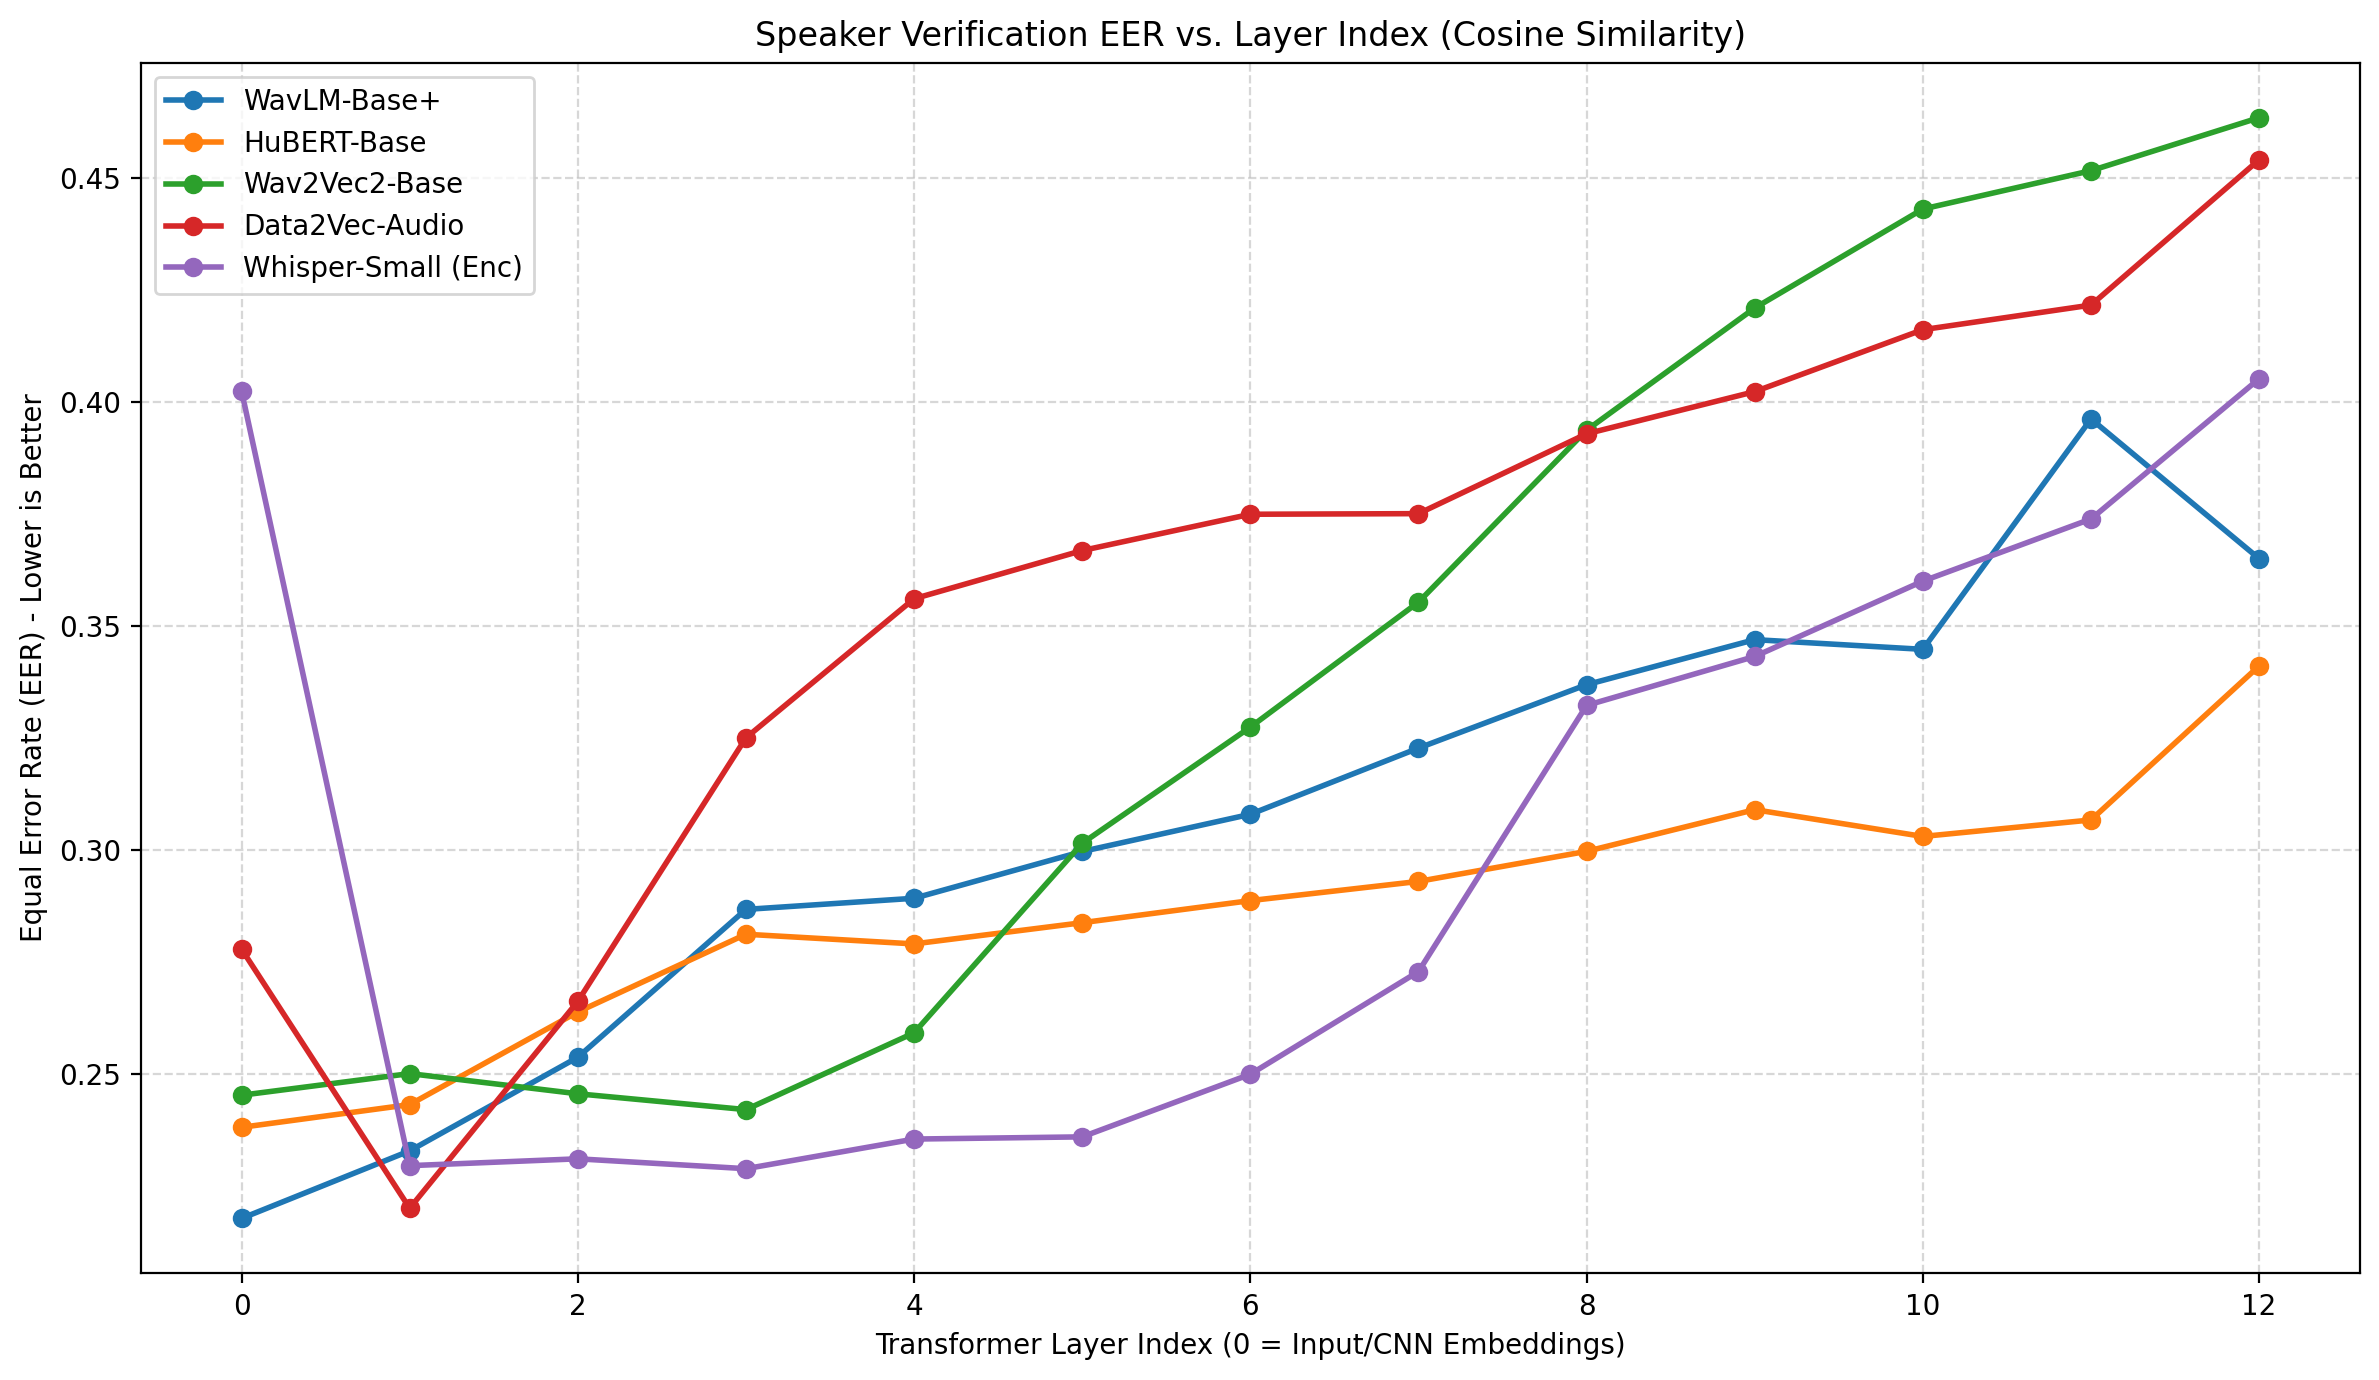


--- Analysis Guidance ---
The EER plot shows how well speaker identity can be distinguished at each layer.
Lower EER indicates better speaker discriminability.
Observe which models and layers achieve the lowest EER, suggesting the most speaker-distinctive representations.
Compare this with your previous speaker probing results (Macro-F1).
Ideally, layers that showed high speaker F1 in probing should also show low EER.


In [3]:
# --- گام ۰: تنظیمات اولیه و مسیرها ---
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from tqdm.auto import tqdm
import warnings
import gc

# Check CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# مسیرهای فایل‌ها و پوشه‌ها
EMBEDDING_DIR = Path("./probing_outputs/hard_speaker_embeddings")
EMBEDDING_INDEX_PATH = EMBEDDING_DIR / "embedding_index_hard.tsv"
OUTPUT_DIR = Path("./verification_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# اطمینان از وجود فایل‌ها
if not EMBEDDING_INDEX_PATH.exists():
    raise FileNotFoundError(f"Embedding index not found at: {EMBEDDING_INDEX_PATH}")
if not EMBEDDING_DIR.exists():
    raise FileNotFoundError(f"Embedding directory not found at: {EMBEDDING_DIR}")

# --- گام ۱: بارگذاری ایندکس Embedding ها ---
print("Loading embedding index...")
embedding_index_df = pd.read_csv(EMBEDDING_INDEX_PATH, sep="\t")

# اطمینان از وجود فایل‌های embedding
missing_embeddings = embedding_index_df["embedding_path"].apply(lambda p: not Path(p).exists())
if missing_embeddings.any():
    print(f"Warning: {missing_embeddings.sum()} embedding files not found. Proceeding with available ones.")
    embedding_index_df = embedding_index_df[~missing_embeddings].reset_index(drop=True)

# -- اطمینان از وجود اطلاعات لازم --
required_cols = {"embedding_path", "speaker", "utterance", "split"}
if not required_cols.issubset(embedding_index_df.columns):
    raise ValueError(f"Embedding index missing required columns. Need: {required_cols}")

# -- encode speaker IDs --
speaker_encoder = LabelEncoder()
embedding_index_df["speaker_id"] = speaker_encoder.fit_transform(embedding_index_df["speaker"])
unique_speakers = embedding_index_df["speaker"].nunique()
print(f"Loaded index for {len(embedding_index_df)} utterances from {unique_speakers} speakers.")

# --- گام ۲: تعریف تابع برای محاسبه EER ---
def calculate_eer(genuine_scores, imposter_scores):
    """
    Calculates the Equal Error Rate (EER) from genuine and imposter scores.
    """
    all_scores = np.concatenate([genuine_scores, imposter_scores])
    labels = np.concatenate([np.ones_like(genuine_scores), np.zeros_like(imposter_scores)])

    def calculate_rates(threshold):
        far = np.mean((imposter_scores >= threshold).astype(int))
        frr = np.mean((genuine_scores < threshold).astype(int))
        return far, frr

    thresholds = np.linspace(min(all_scores), max(all_scores), 1000)
    far_values, frr_values = zip(*(calculate_rates(t) for t in thresholds))

    try:
        eer_threshold = brentq(lambda x: interp1d(thresholds, far_values - frr_values)(x), min(all_scores), max(all_scores))
        eer = interp1d(thresholds, far_values)(eer_threshold)
        return eer
    except:
        # If brentq fails, find the threshold where FAR and FRR are closest
        diffs = np.abs(np.array(far_values) - np.array(frr_values))
        min_diff_idx = np.argmin(diffs)
        return (far_values[min_diff_idx] + frr_values[min_diff_idx]) / 2

# --- گام ۳: استخراج Embedding ها با CUDA و پردازش دسته‌ای ---
# Load a sample to see what models are available
sample_item_path = embedding_index_df.iloc[0]["embedding_path"]
sample_item = torch.load(sample_item_path, map_location="cpu")
available_models = list(sample_item["embeddings"].keys())
print(f"Available models in embeddings: {available_models}")

MODEL_NAMES = available_models

# Load all embeddings to GPU in smaller batches
BATCH_SIZE = 50  # Reduced from 100 to save memory
all_utterances = []

print(f"Loading embeddings to {device}...")
for start_idx in tqdm(range(0, len(embedding_index_df), BATCH_SIZE), desc="Loading embedding batches"):
    end_idx = min(start_idx + BATCH_SIZE, len(embedding_index_df))
    batch_indices = range(start_idx, end_idx)
    
    for idx in batch_indices:
        row = embedding_index_df.iloc[idx]
        try:
            item = torch.load(row["embedding_path"], map_location="cpu")
            
            # Move embeddings to GPU
            for model_name in item["embeddings"]:
                for pool_type in item["embeddings"][model_name]:
                    item["embeddings"][model_name][pool_type] = [
                        tensor.to(device) for tensor in item["embeddings"][model_name][pool_type]
                    ]
            
            all_utterances.append({
                "index": idx,
                "path": row["embedding_path"],
                "speaker_id": row["speaker_id"],
                "utterance_id": row["utterance"],
                "embeddings": item["embeddings"]
            })
        except Exception as e:
            print(f"Error loading {row['embedding_path']}: {e}")
            continue

print(f"Successfully loaded {len(all_utterances)} utterances to {device}")

# Free up memory
del sample_item
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- گام ۳.۵: پردازش دسته‌ای با ماتریس‌ها و ذخیره‌سازی کارآمد ---
def compute_cosine_similarity_batch(embeddings1, embeddings2):
    """Compute cosine similarity between two sets of embeddings using matrix operations on GPU"""
    emb1_norm = embeddings1 / embeddings1.norm(dim=-1, keepdim=True)
    emb2_norm = embeddings2 / embeddings2.norm(dim=-1, keepdim=True)
    similarity = torch.mm(emb1_norm, emb2_norm.t())
    return similarity

# Organize embeddings by model and layer
print("Organizing embeddings for batch processing...")
model_layers = {}

for model_name in MODEL_NAMES:
    model_layers[model_name] = {}
    num_layers = len(all_utterances[0]["embeddings"][model_name]["mean"])
    
    for layer_idx in range(num_layers):
        embeddings_list = []
        speaker_ids = []
        
        for utt in all_utterances:
            embeddings_list.append(utt["embeddings"][model_name]["mean"][layer_idx])
            speaker_ids.append(utt["speaker_id"])
        
        embeddings_tensor = torch.stack(embeddings_list)
        speaker_ids_tensor = torch.tensor(speaker_ids, device=device)
        
        model_layers[model_name][layer_idx] = {
            "embeddings": embeddings_tensor,
            "speaker_ids": speaker_ids_tensor
        }

# Clean up individual embeddings
print("Cleaning up memory...")
for utt in all_utterances:
    model_names = list(utt["embeddings"].keys())
    for model_name in model_names:
        pool_types = list(utt["embeddings"][model_name].keys())
        for pool_type in pool_types:
            del utt["embeddings"][model_name][pool_type]
        del utt["embeddings"][model_name]
    del utt["embeddings"]

del all_utterances
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- OPTIMIZED: Process and store results efficiently ---
print("Computing cosine similarities using batch matrix operations...")

# Create DataFrames incrementally and save to disk to avoid memory issues
all_results_dfs = []

for model_name in tqdm(MODEL_NAMES, desc="Processing models"):
    model_results = []
    
    for layer_idx in tqdm(model_layers[model_name].keys(), desc=f"Processing layers for {model_name}", leave=False):
        data = model_layers[model_name][layer_idx]
        embeddings = data["embeddings"]
        speaker_ids = data["speaker_ids"]
        n_utterances = embeddings.shape[0]
        
        # Compute full similarity matrix on GPU
        similarity_matrix = compute_cosine_similarity_batch(embeddings, embeddings)
        
        # Get upper triangular indices
        triu_indices = torch.triu_indices(n_utterances, n_utterances, offset=1)
        
        # Extract similarities and speaker pairs
        similarities = similarity_matrix[triu_indices[0], triu_indices[1]]
        speaker1_ids = speaker_ids[triu_indices[0]]
        speaker2_ids = speaker_ids[triu_indices[1]]
        is_same_speaker = (speaker1_ids == speaker2_ids)
        
        # Convert to numpy
        similarities_np = similarities.cpu().numpy()
        is_same_speaker_np = is_same_speaker.cpu().numpy()
        speaker1_np = speaker1_ids.cpu().numpy()
        speaker2_np = speaker2_ids.cpu().numpy()
        
        # Create DataFrame for this layer
        layer_df = pd.DataFrame({
            'speaker1_id': speaker1_np,
            'speaker2_id': speaker2_np,
            'is_same_speaker': is_same_speaker_np,
            'cosine_similarity': similarities_np,
            'model': model_name,
            'layer': layer_idx
        })
        
        model_results.append(layer_df)
        
        # Clear GPU memory for this layer
        del similarity_matrix, similarities, speaker1_ids, speaker2_ids, is_same_speaker
        del similarities_np, is_same_speaker_np, speaker1_np, speaker2_np
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Combine results for this model and save to disk
    if model_results:
        model_df = pd.concat(model_results, ignore_index=True)
        # Save immediately to disk to free memory
        model_df.to_csv(OUTPUT_DIR / f"cosine_similarity_{model_name}.csv", index=False)
        print(f"Saved results for {model_name} ({len(model_df)} pairs)")
        all_results_dfs.append(model_df)
        del model_df, model_results
        gc.collect()

# --- Combine all results ---
print("Combining all results...")
if all_results_dfs:
    verification_df = pd.concat(all_results_dfs, ignore_index=True)
    # Save full combined file
    verification_df.to_csv(OUTPUT_DIR / "cosine_similarity_scores_full.csv", index=False)
    print(f"Saved full results to {OUTPUT_DIR / 'cosine_similarity_scores_full.csv'}")
else:
    raise ValueError("No verification results were collected. Check your embedding files and model names.")

# --- Clean up model_layers ---
for model_name in model_layers:
    for layer_idx in model_layers[model_name]:
        if "embeddings" in model_layers[model_name][layer_idx]:
            del model_layers[model_name][layer_idx]["embeddings"]
        if "speaker_ids" in model_layers[model_name][layer_idx]:
            del model_layers[model_name][layer_idx]["speaker_ids"]
del model_layers
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- گام ۴: محاسبه EER برای هر مدل و لایه ---
print(f"Verification DataFrame shape: {verification_df.shape}")
print(f"Unique models: {verification_df['model'].unique()}")

eer_results = []

print("Calculating EER for each model and layer...")
for model_name in MODEL_NAMES:
    model_df = verification_df[verification_df["model"] == model_name]
    if model_df.empty:
        print(f"Warning: No data for model {model_name}")
        continue
    
    layers = model_df["layer"].unique()
    
    for layer_idx in tqdm(sorted(layers), desc=f"EER for {model_name}"):
        layer_df = model_df[model_df["layer"] == layer_idx]
        if layer_df.empty:
            continue
            
        genuine_scores = layer_df[layer_df["is_same_speaker"] == True]["cosine_similarity"].values
        imposter_scores = layer_df[layer_df["is_same_speaker"] == False]["cosine_similarity"].values

        if len(genuine_scores) > 0 and len(imposter_scores) > 0:
            try:
                eer = calculate_eer(genuine_scores, imposter_scores)
                eer_results.append({
                    "model": model_name,
                    "layer": layer_idx,
                    "eer": eer,
                    "num_genuine_pairs": len(genuine_scores),
                    "num_imposter_pairs": len(imposter_scores)
                })
            except Exception as e:
                print(f"Error calculating EER for {model_name} layer {layer_idx}: {e}")
                eer_results.append({
                    "model": model_name,
                    "layer": layer_idx,
                    "eer": np.nan,
                    "num_genuine_pairs": len(genuine_scores),
                    "num_imposter_pairs": len(imposter_scores)
                })
        else:
             eer_results.append({
                "model": model_name,
                "layer": layer_idx,
                "eer": np.nan,
                "num_genuine_pairs": len(genuine_scores),
                "num_imposter_pairs": len(imposter_scores)
            })

eer_summary_df = pd.DataFrame(eer_results)

# --- گام ۵: ذخیره نتایج و نمایش ---
eer_summary_df.to_csv(OUTPUT_DIR / "speaker_verification_eer_summary.csv", index=False)
print(f"Saved EER summary to {OUTPUT_DIR / 'speaker_verification_eer_summary.csv'}")

print("\n--- EER Summary (Lower is Better) ---")
print(eer_summary_df.sort_values("eer").to_string())

# --- گام ۶: رسم نمودار EER ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not eer_summary_df.empty:
    plt.figure(figsize=(12, 7), dpi=200)

    for model_name in MODEL_NAMES:
        sub_df = eer_summary_df[eer_summary_df["model"] == model_name].sort_values("layer")
        if not sub_df.empty and not sub_df["eer"].isna().all():
            plt.plot(
                sub_df["layer"],
                sub_df["eer"],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model_name
            )

    plt.xlabel("Transformer Layer Index (0 = Input/CNN Embeddings)")
    plt.ylabel("Equal Error Rate (EER) - Lower is Better")
    plt.title("Speaker Verification EER vs. Layer Index (Cosine Similarity)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()

    plot_path = OUTPUT_DIR / "speaker_verification_eer_plot.png"
    plt.savefig(plot_path)
    print(f"\nSaved EER plot to {plot_path}")
    plt.show()
else:
    print("No EER results to plot. Check your data.")

print("\n--- Analysis Guidance ---")
print("The EER plot shows how well speaker identity can be distinguished at each layer.")
print("Lower EER indicates better speaker discriminability.")
print("Observe which models and layers achieve the lowest EER, suggesting the most speaker-distinctive representations.")
print("Compare this with your previous speaker probing results (Macro-F1).")
print("Ideally, layers that showed high speaker F1 in probing should also show low EER.")

### برای گام بعدی، آزمایش مقایسه‌ای Mean Pooling در برابر Mean+Std Pooling را انجام می‌دهیم.

/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
GPU Memory: 8.59 GB
Loading embedding index...
Total samples: 2000 (Train: 1200, Test: 500)
Number of speakers: 100
Loading ALL embeddings into RAM (this may take a moment)...


Loading .pt files: 100%|███████████████████████████████████████████████████████████| 2000/2000 [00:55<00:00, 35.83it/s]


Loaded 2000 embedding files into RAM
Organizing embeddings for fast access...


Extracting Whisper-Small (Enc): 100%|██████████████████████████████████████████████████| 13/13 [00:01<00:00, 11.38it/s]


...


Evaluating Model: Data2Vec-Audio (13 layers)...


Probing Data2Vec-Audio: 100%|███████████████████████████████████████████████████████| 13/13 [00:15<00:00,  1.19s/it]



Evaluating Model: Whisper-Small (Enc) (13 layers)...


Probing Whisper-Small (Enc): 100%|██████████████████████████████████████████████████| 13/13 [00:15<00:00,  1.21s/it]



Saved comparison summary to: probing_outputs/pooling_comparison_results/pooling_comparison_summary.csv
Saved comparison plot to: probing_outputs/pooling_comparison_results/pooling_comparison_plot.png


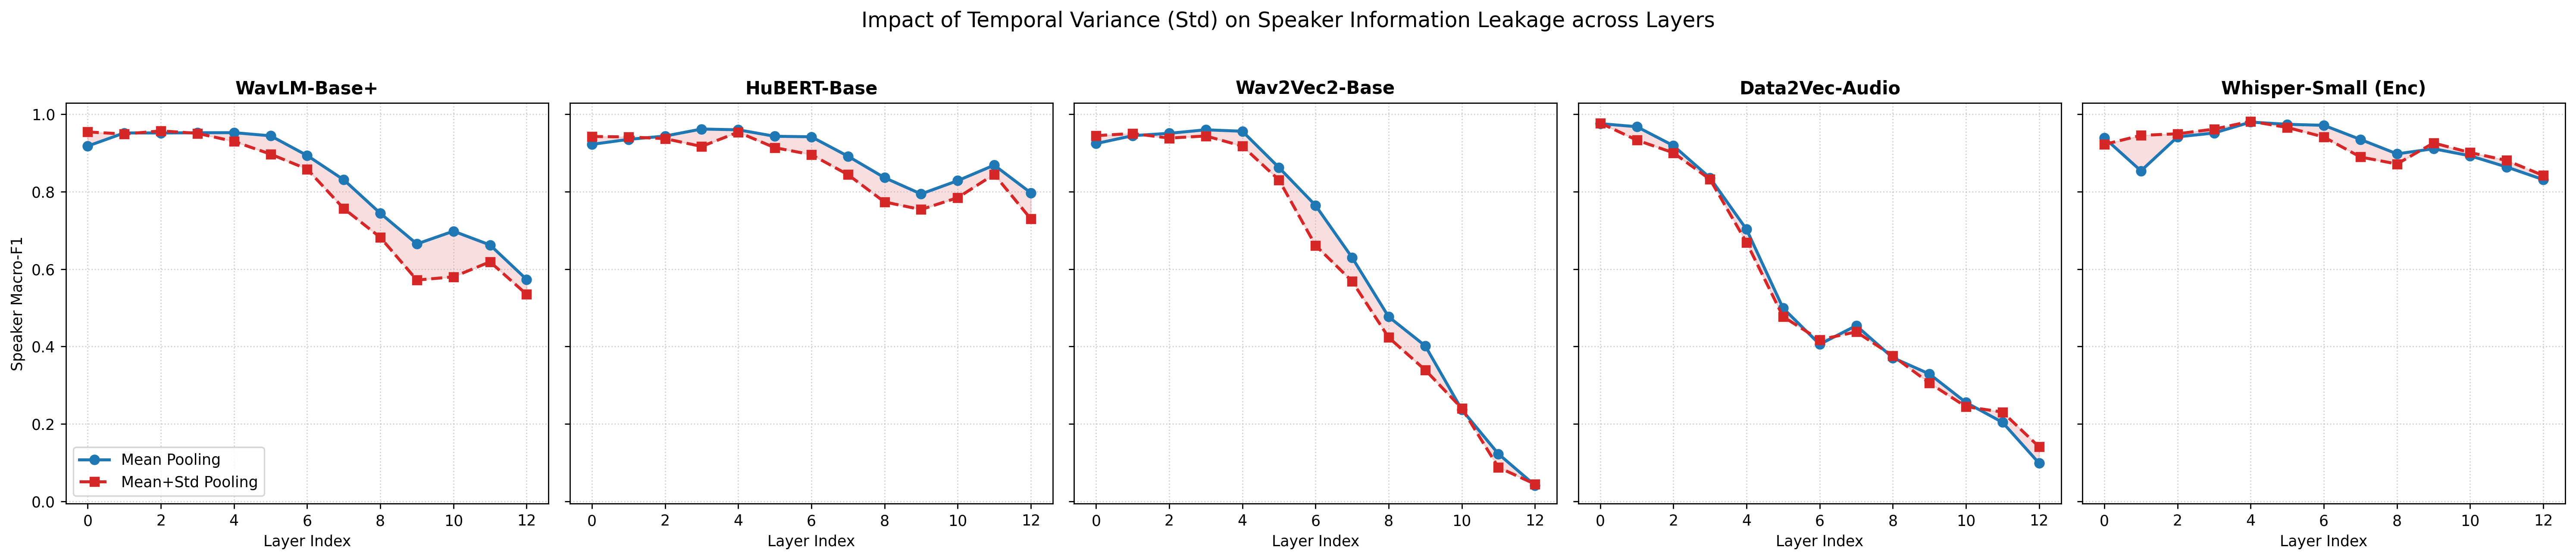


--- Top Layers with Highest Speaker Leakage in Temporal Variance (Delta F1 > 0) ---
              model  layer  f1_mean  f1_mean_std  delta_f1
Whisper-Small (Enc)      1 0.853802     0.945434  0.091632
     Data2Vec-Audio     12 0.098456     0.140748  0.042292
        WavLM-Base+      0 0.917886     0.954341  0.036455
     Data2Vec-Audio     11 0.204125     0.230746  0.026621
        HuBERT-Base      0 0.922238     0.942679  0.020441
      Wav2Vec2-Base      0 0.924330     0.944734  0.020404
Whisper-Small (Enc)     11 0.863766     0.880722  0.016957
Whisper-Small (Enc)      9 0.910940     0.925898  0.014958
     Data2Vec-Audio      6 0.405745     0.417483  0.011739
Whisper-Small (Enc)     12 0.831147     0.841804  0.010657

--- Layers where Mean+Std Significantly Outperforms Mean (Delta F1 > 0.05) ---
              model  layer  f1_mean  f1_mean_std  delta_f1
Whisper-Small (Enc)      1 0.853802     0.945434  0.091632

--- Models Summary (Average Delta F1 per Model) ---
               

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gc
import pickle

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# ۱. تنظیمات و مسیرها
# ==========================================
EMBEDDING_DIR = Path("./probing_outputs/hard_speaker_embeddings")
EMBEDDING_INDEX_PATH = EMBEDDING_DIR / "embedding_index_hard.tsv"
OUTPUT_DIR = Path("./probing_outputs/pooling_comparison_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = [
    'WavLM-Base+',
    'HuBERT-Base',
    'Wav2Vec2-Base',
    'Data2Vec-Audio',
    'Whisper-Small (Enc)'
]

# Check CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ==========================================
# ۲. بارگذاری داده‌ها و تفکیک Train / Test
# ==========================================
print("Loading embedding index...")
index_df = pd.read_csv(EMBEDDING_INDEX_PATH, sep="\t")

label_encoder = LabelEncoder()
index_df["label"] = label_encoder.fit_transform(index_df["speaker"])

train_df = index_df[index_df["split"] == "train"].reset_index(drop=True)
test_df = index_df[index_df["split"] == "test"].reset_index(drop=True)

# اگر ستون split موجود نبود (تفکیک 80/20 بر اساس utterance)
if len(train_df) == 0 or len(test_df) == 0:
    print("Split column not found or empty, creating 80/20 stratified split per speaker...")
    train_indices = []
    test_indices = []
    for spk, group in index_df.groupby("speaker"):
        indices = group.index.tolist()
        n_train = int(len(indices) * 0.8)
        train_indices.extend(indices[:n_train])
        test_indices.extend(indices[n_train:])
    train_df = index_df.loc[train_indices].reset_index(drop=True)
    test_df = index_df.loc[test_indices].reset_index(drop=True)

print(f"Total samples: {len(index_df)} (Train: {len(train_df)}, Test: {len(test_df)})")
print(f"Number of speakers: {len(label_encoder.classes_)}")

# ==========================================
# ۲.۵: بارگذاری هوشمند با کش کردن در RAM
# ==========================================
# Strategy: Load ALL embeddings into RAM once, then process
# This uses more RAM but eliminates disk I/O

print("Loading ALL embeddings into RAM (this may take a moment)...")
cached_data = {}

# Load all files with progress bar
for p in tqdm(index_df["embedding_path"].unique(), desc="Loading .pt files"):
    try:
        cached_data[p] = torch.load(p, map_location="cpu")
    except Exception as e:
        print(f"Error loading {p}: {e}")

print(f"Loaded {len(cached_data)} embedding files into RAM")

# ==========================================
# ۲.۶: پیش‌پردازش و ساختاردهی داده‌ها برای دسترسی سریع
# ==========================================
print("Organizing embeddings for fast access...")

# Create a structured dictionary for fast access
# Structure: model_name -> layer_idx -> split -> list of embeddings
embeddings_structured = {}

for model_name in MODEL_NAMES:
    # Check if model exists
    first_pt = cached_data[index_df.iloc[0]["embedding_path"]]
    if model_name not in first_pt["embeddings"]:
        print(f"Skipping {model_name} (not found in embeddings).")
        continue
    
    num_layers = len(first_pt["embeddings"][model_name]["mean"])
    embeddings_structured[model_name] = {
        'num_layers': num_layers,
        'train_mean': [],
        'train_std': [],
        'test_mean': [],
        'test_std': []
    }
    
    # Pre-extract all embeddings for this model
    for layer_idx in tqdm(range(num_layers), desc=f"Extracting {model_name}"):
        train_mean = []
        train_std = []
        test_mean = []
        test_std = []
        
        # Process train set
        for _, row in train_df.iterrows():
            emb_dict = cached_data[row["embedding_path"]]["embeddings"][model_name]
            m = emb_dict["mean"][layer_idx].numpy().flatten()
            train_mean.append(m)
            
            # Handle std
            if "std" in emb_dict:
                s = emb_dict["std"][layer_idx].numpy().flatten()
                train_std.append(np.concatenate([m, s]))
            elif "mean_std" in emb_dict:
                ms = emb_dict["mean_std"][layer_idx].numpy().flatten()
                train_std.append(ms)
            else:
                train_std.append(m)
        
        # Process test set
        for _, row in test_df.iterrows():
            emb_dict = cached_data[row["embedding_path"]]["embeddings"][model_name]
            m = emb_dict["mean"][layer_idx].numpy().flatten()
            test_mean.append(m)
            
            if "std" in emb_dict:
                s = emb_dict["std"][layer_idx].numpy().flatten()
                test_std.append(np.concatenate([m, s]))
            elif "mean_std" in emb_dict:
                ms = emb_dict["mean_std"][layer_idx].numpy().flatten()
                test_std.append(ms)
            else:
                test_std.append(m)
        
        embeddings_structured[model_name]['train_mean'].append(np.array(train_mean))
        embeddings_structured[model_name]['train_std'].append(np.array(train_std))
        embeddings_structured[model_name]['test_mean'].append(np.array(test_mean))
        embeddings_structured[model_name]['test_std'].append(np.array(test_std))
        
        # Clear memory periodically
        if layer_idx % 5 == 0:
            gc.collect()

# Free up the original cached data to save memory (keep structured data)
print("Freeing up memory...")
del cached_data
gc.collect()

# ==========================================
# ۳. اجرای Probing برای هر دو نوع Pooling
# ==========================================
results = []
y_train = train_df["label"].values
y_test = test_df["label"].values

for model_name in MODEL_NAMES:
    if model_name not in embeddings_structured:
        continue
    
    num_layers = embeddings_structured[model_name]['num_layers']
    print(f"\nEvaluating Model: {model_name} ({num_layers} layers)...")
    
    # Get pre-extracted embeddings
    train_mean_layers = embeddings_structured[model_name]['train_mean']
    train_std_layers = embeddings_structured[model_name]['train_std']
    test_mean_layers = embeddings_structured[model_name]['test_mean']
    test_std_layers = embeddings_structured[model_name]['test_std']
    
    for layer_idx in tqdm(range(num_layers), desc=f"Probing {model_name}"):
        X_train_mean = train_mean_layers[layer_idx]
        X_train_mean_std = train_std_layers[layer_idx]
        X_test_mean = test_mean_layers[layer_idx]
        X_test_mean_std = test_std_layers[layer_idx]

        # --- الف) آموزش و ارزیابی Mean Pooling ---
        scaler_m = StandardScaler()
        X_tr_m = scaler_m.fit_transform(X_train_mean)
        X_te_m = scaler_m.transform(X_test_mean)

        clf_m = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
        clf_m.fit(X_tr_m, y_train)
        preds_m = clf_m.predict(X_te_m)
        f1_m = f1_score(y_test, preds_m, average="macro")
        acc_m = accuracy_score(y_test, preds_m)

        # --- ب) آموزش و ارزیابی Mean+Std Pooling ---
        scaler_ms = StandardScaler()
        X_tr_ms = scaler_ms.fit_transform(X_train_mean_std)
        X_te_ms = scaler_ms.transform(X_test_mean_std)

        clf_ms = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
        clf_ms.fit(X_tr_ms, y_train)
        preds_ms = clf_ms.predict(X_te_ms)
        f1_ms = f1_score(y_test, preds_ms, average="macro")
        acc_ms = accuracy_score(y_test, preds_ms)

        results.append({
            "model": model_name,
            "layer": layer_idx,
            "f1_mean": f1_m,
            "acc_mean": acc_m,
            "f1_mean_std": f1_ms,
            "acc_mean_std": acc_ms,
            "delta_f1": f1_ms - f1_m,
            "delta_acc": acc_ms - acc_m,
            "dim_mean": X_train_mean.shape[1],
            "dim_mean_std": X_train_mean_std.shape[1]
        })

# Free structured embeddings
del embeddings_structured
gc.collect()

results_df = pd.DataFrame(results)
csv_save_path = OUTPUT_DIR / "pooling_comparison_summary.csv"
results_df.to_csv(csv_save_path, index=False)
print(f"\nSaved comparison summary to: {csv_save_path}")

# ==========================================
# ۴. رسم نمودارهای مقایسه‌ای برای ژورنال
# ==========================================
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(24, 5), dpi=250, sharey=True)
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    sub_df = results_df[results_df["model"] == model_name].sort_values("layer")
    if sub_df.empty:
        continue

    ax.plot(sub_df["layer"], sub_df["f1_mean"], marker="o", linewidth=2, label="Mean Pooling", color="#1f77b4")
    ax.plot(sub_df["layer"], sub_df["f1_mean_std"], marker="s", linestyle="--", linewidth=2, label="Mean+Std Pooling", color="#d62728")
    
    # نمایش اختلاف‌ها به صورت ناحیه پررنگ در صورت وجود گپ
    ax.fill_between(sub_df["layer"], sub_df["f1_mean"], sub_df["f1_mean_std"], color="#d62728", alpha=0.15)

    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Layer Index")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[0].set_ylabel("Speaker Macro-F1")
axes[0].legend(loc="lower left")

plt.suptitle("Impact of Temporal Variance (Std) on Speaker Information Leakage across Layers", fontsize=14, y=1.03)
plt.tight_layout()

plot_save_path = OUTPUT_DIR / "pooling_comparison_plot.png"
plt.savefig(plot_save_path, bbox_inches="tight")
print(f"Saved comparison plot to: {plot_save_path}")
plt.show()

# ==========================================
# ۵. گزارش‌های اضافی
# ==========================================
print("\n--- Top Layers with Highest Speaker Leakage in Temporal Variance (Delta F1 > 0) ---")
print(results_df.sort_values("delta_f1", ascending=False)[["model", "layer", "f1_mean", "f1_mean_std", "delta_f1"]].head(10).to_string(index=False))

print("\n--- Layers where Mean+Std Significantly Outperforms Mean (Delta F1 > 0.05) ---")
significant = results_df[results_df["delta_f1"] > 0.05].sort_values("delta_f1", ascending=False)
if not significant.empty:
    print(significant[["model", "layer", "f1_mean", "f1_mean_std", "delta_f1"]].head(10).to_string(index=False))
else:
    print("No significant improvements found.")

print("\n--- Models Summary (Average Delta F1 per Model) ---")
model_summary = results_df.groupby("model")["delta_f1"].agg(["mean", "std", "max", "min"]).round(4)
print(model_summary.to_string())

print("\n--- Memory Usage Analysis ---")
print(f"Results DataFrame size: {results_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

### گام بعدی (بررسی ظرفیت مدل‌ها: Linear vs. MLP Probe)

Loading embedding index...
Total samples: 2000 (Train: 1600, Test: 400)
Number of speakers: 100
Pre-loading tensors into memory...


Loading .pt files: 100%|████████████████████████████████████████████████████████| 2000/2000 [00:54<00:00, 37.03it/s]



Evaluating Model: WavLM-Base+ (13 layers) with MLP Probe...


Probing WavLM-Base+:   0%|                                                                   | 0/13 [00:00<?, ?it/s]/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could repre


Evaluating Model: HuBERT-Base (13 layers) with MLP Probe...


...


Evaluating Model: Data2Vec-Audio (13 layers) with MLP Probe...


Probing Data2Vec-Audio:   0%|                                                                | 0/13 [00:00<?, ?it/s]/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could repre


Evaluating Model: Whisper-Small (Enc) (13 layers) with MLP Probe...


Probing Whisper-Small (Enc):   0%|                                                           | 0/13 [00:00<?, ?it/s]/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could repre


Saved MLP probe summary to: probing_outputs/mlp_probe_results/mlp_probe_summary.csv
Saved merged comparison summary to: probing_outputs/mlp_probe_results/mlp_vs_linear_probe_comparison.csv
Saved MLP vs Linear probe plot to: probing_outputs/mlp_probe_results/mlp_vs_linear_probe_plot.png


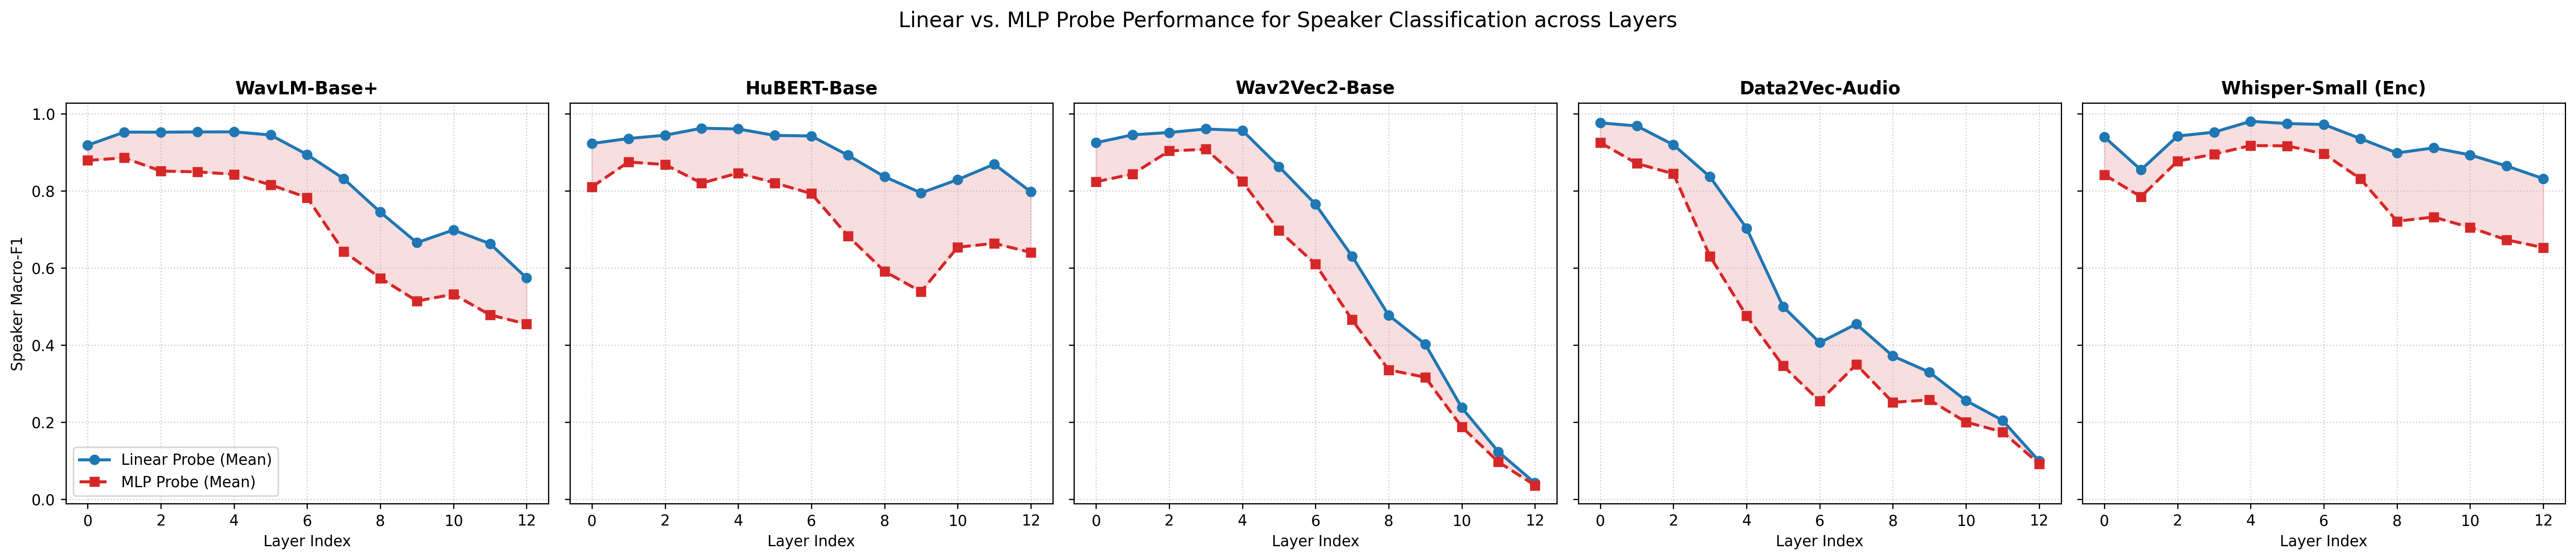


--- Top Layers where MLP Probe Significantly Outperforms Linear Probe (Delta F1 > 0.05) ---
No layers found where MLP probe significantly outperforms Linear probe (Delta F1 > 0.05).

--- Overall Summary of MLP vs Linear Probe Performance ---
Positive Delta F1 indicates MLP found more speaker information than Linear probe.
High positive Delta F1 suggests speaker information is present but not linearly accessible.


In [2]:
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier # MLP Probe
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# ۱. تنظیمات و مسیرها
# ==========================================
EMBEDDING_DIR = Path("./probing_outputs/hard_speaker_embeddings")
EMBEDDING_INDEX_PATH = EMBEDDING_DIR / "embedding_index_hard.tsv"
OUTPUT_DIR = Path("./probing_outputs/mlp_probe_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = [
    'WavLM-Base+',
    'HuBERT-Base',
    'Wav2Vec2-Base',
    'Data2Vec-Audio',
    'Whisper-Small (Enc)'
]

# ==========================================
# ۲. بارگذاری داده‌ها و تفکیک Train / Test
# ==========================================
print("Loading embedding index...")
index_df = pd.read_csv(EMBEDDING_INDEX_PATH, sep="\t")

label_encoder = LabelEncoder()
index_df["label"] = label_encoder.fit_transform(index_df["speaker"])

# تفکیک Train/Test (80/20)
train_indices = []
test_indices = []
for spk, group in index_df.groupby("speaker"):
    indices = group.index.tolist()
    n_train = int(len(indices) * 0.8)
    train_indices.extend(indices[:n_train])
    test_indices.extend(indices[n_train:])
train_df = index_df.loc[train_indices].reset_index(drop=True)
test_df = index_df.loc[test_indices].reset_index(drop=True)

print(f"Total samples: {len(index_df)} (Train: {len(train_df)}, Test: {len(test_df)})")
print(f"Number of speakers: {len(label_encoder.classes_)}")

# بارگذاری پیش‌فرض همه تانسورها در حافظه RAM
print("Pre-loading tensors into memory...")
cached_data = {}
for p in tqdm(index_df["embedding_path"].unique(), desc="Loading .pt files"):
    cached_data[p] = torch.load(p, map_location="cpu")

# ==========================================
# ۳. اجرای MLP Probing برای هر مدل و لایه
# ==========================================
results = []

for model_name in MODEL_NAMES:
    first_pt = cached_data[index_df.iloc[0]["embedding_path"]]
    if model_name not in first_pt["embeddings"]:
        print(f"Skipping {model_name} (not found in embeddings).")
        continue

    num_layers = len(first_pt["embeddings"][model_name]["mean"])
    print(f"\nEvaluating Model: {model_name} ({num_layers} layers) with MLP Probe...")

    for layer_idx in tqdm(range(num_layers), desc=f"Probing {model_name}"):
        
        # استخراج بردارهای Train و Test برای Mean Pooling
        X_train_mean, X_test_mean = [], []
        y_train = train_df["label"].values
        y_test = test_df["label"].values

        for _, row in train_df.iterrows():
            emb_dict = cached_data[row["embedding_path"]]["embeddings"][model_name]
            m = emb_dict["mean"][layer_idx].numpy().flatten()
            X_train_mean.append(m)
        for _, row in test_df.iterrows():
            emb_dict = cached_data[row["embedding_path"]]["embeddings"][model_name]
            m = emb_dict["mean"][layer_idx].numpy().flatten()
            X_test_mean.append(m)

        X_train_mean = np.array(X_train_mean)
        X_test_mean = np.array(X_test_mean)

        # --- آموزش و ارزیابی MLP Probe ---
        scaler_m = StandardScaler()
        X_tr_m = scaler_m.fit_transform(X_train_mean)
        X_te_m = scaler_m.transform(X_test_mean)

        # MLP Classifier parameters - adjust as needed
        # Hidden layer sizes: e.g., (128, 64) means two hidden layers
        # Consider tuning these based on embedding dimensionality
        hidden_layer_dims = (128, 64) if X_tr_m.shape[1] > 128 else (64,) if X_tr_m.shape[1] > 64 else (32,)

        clf_mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_dims,
                                max_iter=500, # Increased max_iter for convergence
                                alpha=0.0001, # L2 penalty
                                learning_rate_init=0.001,
                                random_state=42,
                                early_stopping=True, # Stop if validation score doesn't improve
                                n_iter_no_change=10, # Number of iterations with no improvement to wait
                                validation_fraction=0.1, # Use 10% of training data for early stopping
                                solver='adam' # Adam optimizer
                                )
        
        clf_mlp.fit(X_tr_m, y_train)
        preds_mlp = clf_mlp.predict(X_te_m)
        f1_mlp = f1_score(y_test, preds_mlp, average="macro")
        acc_mlp = accuracy_score(y_test, preds_mlp)

        results.append({
            "model": model_name,
            "layer": layer_idx,
            "f1_mlp": f1_mlp,
            "acc_mlp": acc_mlp,
        })

results_df = pd.DataFrame(results)
csv_save_path = OUTPUT_DIR / "mlp_probe_summary.csv"
results_df.to_csv(csv_save_path, index=False)
print(f"\nSaved MLP probe summary to: {csv_save_path}")

# ==========================================
# ۴. رسم نمودار مقایسه‌ای MLP vs Linear Probe
# ==========================================
# برای مقایسه، نتایج Linear Probe را دوباره بارگذاری می‌کنیم (یا اگر در حافظه هست استفاده می‌کنیم)
try:
    linear_probe_df = pd.read_csv("./probing_outputs/pooling_comparison_results/pooling_comparison_summary.csv")
    # Keep only 'mean' pooling results for comparison
    linear_probe_df = linear_probe_df[linear_probe_df.columns.intersection(["model", "layer", "f1_mean", "acc_mean"])]
    linear_probe_df = linear_probe_df.rename(columns={"f1_mean": "f1_linear", "acc_mean": "acc_linear"})
except FileNotFoundError:
    print("Linear probe results not found. Please run the pooling comparison script first.")
    linear_probe_df = None

if linear_probe_df is not None:
    # Merge MLP results with Linear probe results
    merged_df = pd.merge(results_df, linear_probe_df, on=["model", "layer"], how="left")

    # Calculate the difference
    merged_df["delta_f1_mlp_vs_linear"] = merged_df["f1_mlp"] - merged_df["f1_linear"]

    # Save merged results
    merged_csv_path = OUTPUT_DIR / "mlp_vs_linear_probe_comparison.csv"
    merged_df.to_csv(merged_csv_path, index=False)
    print(f"Saved merged comparison summary to: {merged_csv_path}")

    # Plotting
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(24, 5), dpi=250, sharey=True)
    if len(MODEL_NAMES) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, MODEL_NAMES):
        sub_df = merged_df[merged_df["model"] == model_name].sort_values("layer")
        if sub_df.empty:
            continue

        ax.plot(sub_df["layer"], sub_df["f1_linear"], marker="o", linewidth=2, label="Linear Probe (Mean)", color="#1f77b4")
        ax.plot(sub_df["layer"], sub_df["f1_mlp"], marker="s", linestyle="--", linewidth=2, label="MLP Probe (Mean)", color="#d62728")
        
        # Highlight areas where MLP significantly outperforms Linear
        ax.fill_between(sub_df["layer"], sub_df["f1_linear"], sub_df["f1_mlp"], color="#d62728", alpha=0.15)

        ax.set_title(model_name, fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer Index")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[0].set_ylabel("Speaker Macro-F1")
    axes[0].legend(loc="lower left")

    plt.suptitle("Linear vs. MLP Probe Performance for Speaker Classification across Layers", fontsize=14, y=1.03)
    plt.tight_layout()

    plot_save_path = OUTPUT_DIR / "mlp_vs_linear_probe_plot.png"
    plt.savefig(plot_save_path, bbox_inches="tight")
    print(f"Saved MLP vs Linear probe plot to: {plot_save_path}")
    plt.show()

    # چاپ خلاصه بیشترین تفاوت‌ها
    print("\n--- Top Layers where MLP Probe Significantly Outperforms Linear Probe (Delta F1 > 0.05) ---")
    significant_diff = merged_df[merged_df["delta_f1_mlp_vs_linear"] > 0.05]
    if not significant_diff.empty:
        print(significant_diff[["model", "layer", "f1_linear", "f1_mlp", "delta_f1_mlp_vs_linear"]].sort_values("delta_f1_mlp_vs_linear", ascending=False).to_string(index=False))
    else:
        print("No layers found where MLP probe significantly outperforms Linear probe (Delta F1 > 0.05).")

    print("\n--- Overall Summary of MLP vs Linear Probe Performance ---")
    print("Positive Delta F1 indicates MLP found more speaker information than Linear probe.")
    print("High positive Delta F1 suggests speaker information is present but not linearly accessible.")


###  (تحلیل همبستگی ویژگی‌های آکوستیک پایه: F0/Pitch و Energy با لایه‌های مدل‌ها)

/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Audio directory: /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed
Loading embedding index...
Available columns: ['row_index', 'embedding_path', 'path', 'speaker', 'utterance', 'split']
Total samples: 2000
Sample utterance values: [59, 155, 57, 330, 295]
Sample speaker values: ['p263', 'p301', 'p267', 'p262', 'p295']
Building audio file index from /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed...
Found 88328 audio files in /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed
Example audio files: ['p225_001_mic1', 'p225_001_mic2', 'p225_002_mic1', 'p225_002_mic2', 'p225_003_mic1']
Constructing audio paths from utterance IDs...


Finding audio files: 100%|█████████████████████████████████████████████████████| 2000/2000 [00:15<00:00, 130.94it/s]


Found audio paths for 2000/2000 utterances
Success rate: 100.0%
Valid samples with audio: 2000
Extracting F0 (pyin) and Energy (RMS) from audio files...


Extracting Acoustic Features: 100%|█████████████████████████████████████████████| 2000/2000 [08:10<00:00,  4.07it/s]


...


Probing Model: Data2Vec-Audio (13 layers)...


Probing Data2Vec-Audio: 100%|███████████████████████████████████████████████████████| 13/13 [00:03<00:00,  3.82it/s]



Probing Model: Whisper-Small (Enc) (13 layers)...


Probing Whisper-Small (Enc): 100%|██████████████████████████████████████████████████| 13/13 [00:03<00:00,  4.02it/s]



Saved R2 summary to: probing_outputs/acoustic_probing_results/acoustic_probing_r2_summary.csv
Saved plot to: probing_outputs/acoustic_probing_results/acoustic_probing_r2_curves.png


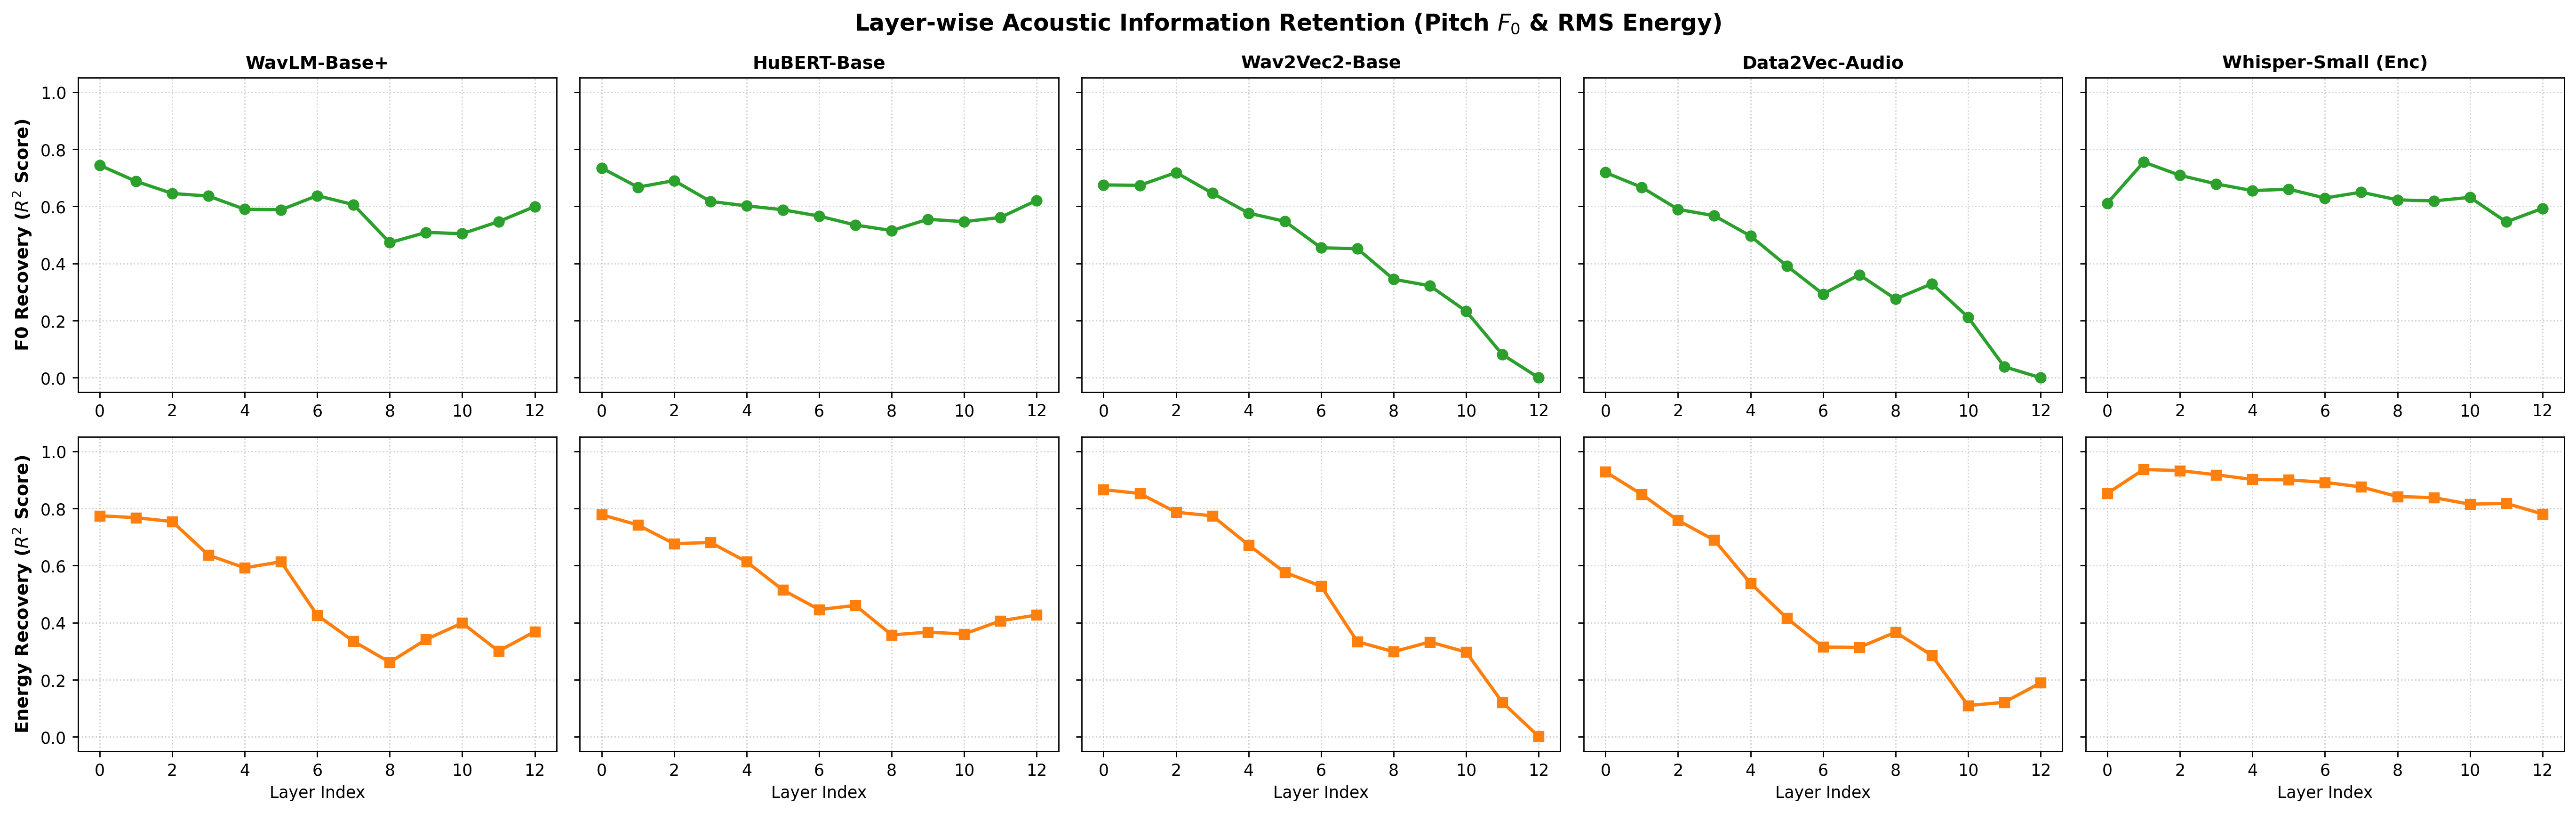


--- Best Layers for Acoustic Probing ---
WavLM-Base+:
  Best F0: Layer 0 (R²=0.744)
  Best Energy: Layer 0 (R²=0.775)
HuBERT-Base:
  Best F0: Layer 0 (R²=0.734)
  Best Energy: Layer 0 (R²=0.778)
Wav2Vec2-Base:
  Best F0: Layer 2 (R²=0.718)
  Best Energy: Layer 0 (R²=0.866)
Data2Vec-Audio:
  Best F0: Layer 0 (R²=0.718)
  Best Energy: Layer 0 (R²=0.928)
Whisper-Small (Enc):
  Best F0: Layer 1 (R²=0.755)
  Best Energy: Layer 1 (R²=0.937)


In [1]:
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import gc
import glob

# ==========================================
# ۱. تنظیمات و مسیرها
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EMBEDDING_DIR = Path("./probing_outputs/hard_speaker_embeddings")
EMBEDDING_INDEX_PATH = EMBEDDING_DIR / "embedding_index_hard.tsv"
OUTPUT_DIR = Path("./probing_outputs/acoustic_probing_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ۲. مشخص کردن مسیر فایل‌های صوتی VCTK
# ==========================================
# Set the correct path to your VCTK dataset
AUDIO_DIR = Path(r"/mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed")
print(f"Audio directory: {AUDIO_DIR}")

if not AUDIO_DIR.exists():
    print(f"ERROR: Audio directory not found at {AUDIO_DIR}")
    print("Please update the path to your VCTK dataset.")
    exit()

# VCTK dataset structure: speaker folders, each containing .flac files
# Example: wav48_silence_trimmed/p225/p225_001.flac

MODEL_NAMES = [
    'WavLM-Base+',
    'HuBERT-Base',
    'Wav2Vec2-Base',
    'Data2Vec-Audio',
    'Whisper-Small (Enc)'
]

# ==========================================
# ۳. بارگذاری ایندکس
# ==========================================
print("Loading embedding index...")
index_df = pd.read_csv(EMBEDDING_INDEX_PATH, sep="\t")

# Check what columns are available
print(f"Available columns: {index_df.columns.tolist()}")
print(f"Total samples: {len(index_df)}")
print(f"Sample utterance values: {index_df['utterance'].head().tolist()}")
print(f"Sample speaker values: {index_df['speaker'].head().tolist()}")

# ==========================================
# ۴. ساخت لیست فایل‌های صوتی موجود از VCTK
# ==========================================
print(f"Building audio file index from {AUDIO_DIR}...")
audio_files = {}
all_audio_files = []

# Search for all .flac files in all speaker subdirectories
for audio_file in AUDIO_DIR.glob("**/*.flac"):
    all_audio_files.append(audio_file)
    # Store with both full path stem and filename
    audio_files[audio_file.stem] = audio_file
    # Also store just the filename without path
    audio_files[audio_file.name.replace('.flac', '')] = audio_file

print(f"Found {len(all_audio_files)} audio files in {AUDIO_DIR}")

if len(all_audio_files) == 0:
    print("ERROR: No .flac files found! Please check your VCTK dataset path.")
    print(f"Current AUDIO_DIR: {AUDIO_DIR}")
    print("Contents of directory:")
    for item in AUDIO_DIR.iterdir():
        print(f"  {item}")
    exit()

# Show some example audio files
print(f"Example audio files: {[f.stem for f in all_audio_files[:5]]}")

# ==========================================
# ۵. یافتن مسیر صوتی برای هر utterance
# ==========================================
print("Constructing audio paths from utterance IDs...")
audio_paths = []
found_count = 0
not_found_utterances = []

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Finding audio files"):
    utterance = row["utterance"]
    speaker = row["speaker"]
    
    audio_path = None
    
    # VCTK naming convention: {speaker}_{utterance}.flac
    # Example: p225_001.flac
    possible_filenames = [
        f"{speaker}_{utterance}",  # p225_001
        f"{utterance}",            # 001
    ]
    
    # Add padded version if utterance is integer
    if isinstance(utterance, int):
        possible_filenames.append(f"{speaker}_{utterance:03d}")
    
    # Try different possible filenames
    for filename in possible_filenames:
        if filename in audio_files:
            audio_path = str(audio_files[filename])
            found_count += 1
            break
    
    # If not found, try to search in speaker-specific directory
    if audio_path is None:
        speaker_dir = AUDIO_DIR / speaker
        if speaker_dir.exists():
            # Look for files that contain the utterance number
            for audio_file in speaker_dir.glob(f"*_{utterance}.flac"):
                audio_path = str(audio_file)
                found_count += 1
                break
            # Or just any file with the utterance number
            if audio_path is None:
                for audio_file in speaker_dir.glob(f"*{utterance}*.flac"):
                    audio_path = str(audio_file)
                    found_count += 1
                    break
    
    # If still not found, try a broader search
    if audio_path is None:
        # Search for any file containing the utterance number
        utterance_str = str(utterance)
        for file_stem in audio_files:
            if utterance_str in file_stem:
                audio_path = str(audio_files[file_stem])
                found_count += 1
                break
    
    if audio_path is None:
        not_found_utterances.append(f"{speaker}_{utterance}")
    
    audio_paths.append(audio_path if audio_path is not None else "")

index_df["audio_path"] = audio_paths
print(f"Found audio paths for {found_count}/{len(index_df)} utterances")
print(f"Success rate: {found_count/len(index_df)*100:.1f}%")

if found_count < len(index_df):
    print(f"Sample of not found utterances: {not_found_utterances[:10]}")

# ==========================================
# ۶. فیلتر کردن نمونه‌های بدون فایل صوتی
# ==========================================
valid_audio_mask = index_df["audio_path"] != ""
if (~valid_audio_mask).any():
    invalid_count = sum(~valid_audio_mask)
    print(f"Warning: {invalid_count} rows missing audio paths. These will be excluded from acoustic probing.")
    missing_samples = index_df[~valid_audio_mask][['speaker', 'utterance']].head(10)
    print(f"Sample missing utterances: {missing_samples.values.tolist()}")
    index_df = index_df[valid_audio_mask].reset_index(drop=True)

if len(index_df) == 0:
    print("ERROR: No valid samples with audio paths found!")
    print("Please check the mapping between utterance IDs and audio file names.")
    print(f"Example audio filenames in VCTK: {[f.stem for f in all_audio_files[:10]]}")
    exit()

print(f"Valid samples with audio: {len(index_df)}")

# ==========================================
# ۷. استخراج ویژگی‌های F0 و Energy
# ==========================================
# Use CSV for caching (no need for pyarrow/fastparquet)
acoustic_cache_file_csv = OUTPUT_DIR / "acoustic_targets_cache.csv"

if acoustic_cache_file_csv.exists():
    print("Loading cached acoustic targets from CSV...")
    acoustic_df = pd.read_csv(acoustic_cache_file_csv)
    print("Successfully loaded cached acoustic targets.")
else:
    print("Extracting F0 (pyin) and Energy (RMS) from audio files...")
    f0_means, f0_stds = [], []
    energy_means, energy_stds = [], []
    successful_files = 0

    for idx, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Extracting Acoustic Features"):
        audio_path = row["audio_path"]
        
        try:
            # بارگذاری صوت (16kHz استاندارد)
            y, sr = sf.read(audio_path)
            if y.ndim > 1:
                y = np.mean(y, axis=1)
            if sr != 16000:
                y = librosa.resample(y, orig_sr=sr, target_sr=16000)
                sr = 16000

            # محاسبه F0 با الگوریتم pyin
            f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr, frame_length=1024)
            voiced_f0 = f0[voiced_flag & (~np.isnan(f0))]

            if len(voiced_f0) > 0:
                f0_means.append(np.mean(voiced_f0))
                f0_stds.append(np.std(voiced_f0))
            else:
                f0_means.append(0.0)
                f0_stds.append(0.0)

            # محاسبه RMS Energy
            rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=512)[0]
            energy_means.append(np.mean(rms))
            energy_stds.append(np.std(rms))
            successful_files += 1
            
        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
            f0_means.append(0.0)
            f0_stds.append(0.0)
            energy_means.append(0.0)
            energy_stds.append(0.0)

    index_df["f0_mean"] = f0_means
    index_df["f0_std"] = f0_stds
    index_df["energy_mean"] = energy_means
    index_df["energy_std"] = energy_stds

    # Save as CSV (no dependency needed)
    index_df.to_csv(acoustic_cache_file_csv, index=False)
    acoustic_df = index_df
    print(f"Saved CSV cache to: {acoustic_cache_file_csv}")
    print(f"Successfully extracted features from {successful_files}/{len(index_df)} files")

# ==========================================
# ۸. تفکیک Train / Test
# ==========================================
# تفکیک Train / Test (80/20) بر اساس گوینده
train_indices, test_indices = [], []
for spk, group in acoustic_df.groupby("speaker"):
    indices = group.index.tolist()
    n_train = int(len(indices) * 0.8)
    train_indices.extend(indices[:n_train])
    test_indices.extend(indices[n_train:])

train_df = acoustic_df.loc[train_indices].reset_index(drop=True)
test_df = acoustic_df.loc[test_indices].reset_index(drop=True)

print(f"Train: {len(train_df)} samples, Test: {len(test_df)} samples")

# ==========================================
# ۹. پیش‌بارگذاری تانسورها
# ==========================================
print("Pre-loading representation embeddings into RAM...")
cached_data = {}
# Load only the embeddings we need (for the valid samples)
unique_embeddings = set(acoustic_df["embedding_path"].unique())
for p in tqdm(unique_embeddings, desc="Loading .pt files"):
    try:
        cached_data[p] = torch.load(p, map_location="cpu")
    except Exception as e:
        print(f"Error loading {p}: {e}")

# ==========================================
# ۱۰. اجرای Acoustic Probing (Ridge Regression)
# ==========================================
results = []
targets = {
    "F0_Mean": ("f0_mean", train_df["f0_mean"].values, test_df["f0_mean"].values),
    "Energy_Mean": ("energy_mean", train_df["energy_mean"].values, test_df["energy_mean"].values)
}

for model_name in MODEL_NAMES:
    # Check if model exists
    if len(cached_data) == 0:
        print("No cached data available. Skipping...")
        break
        
    # Check if first sample has this model
    first_pt = cached_data[acoustic_df.iloc[0]["embedding_path"]]
    if model_name not in first_pt["embeddings"]:
        print(f"Model {model_name} not found in embeddings. Skipping...")
        continue

    num_layers = len(first_pt["embeddings"][model_name]["mean"])
    print(f"\nProbing Model: {model_name} ({num_layers} layers)...")

    # Pre-extract embeddings for this model
    train_embeddings = []
    test_embeddings = []
    
    for layer_idx in tqdm(range(num_layers), desc=f"Extracting {model_name}"):
        # Extract train embeddings
        X_train = []
        for _, row in train_df.iterrows():
            try:
                emb = cached_data[row["embedding_path"]]["embeddings"][model_name]["mean"][layer_idx].numpy().flatten()
                X_train.append(emb)
            except Exception as e:
                print(f"Error extracting train embedding for {model_name} layer {layer_idx}: {e}")
                X_train.append(np.zeros(768))  # placeholder
        
        # Extract test embeddings
        X_test = []
        for _, row in test_df.iterrows():
            try:
                emb = cached_data[row["embedding_path"]]["embeddings"][model_name]["mean"][layer_idx].numpy().flatten()
                X_test.append(emb)
            except Exception as e:
                print(f"Error extracting test embedding for {model_name} layer {layer_idx}: {e}")
                X_test.append(np.zeros(768))  # placeholder
        
        train_embeddings.append(np.array(X_train))
        test_embeddings.append(np.array(X_test))
    
    # Now run regression for each layer
    for layer_idx in tqdm(range(num_layers), desc=f"Probing {model_name}"):
        X_train = train_embeddings[layer_idx]
        X_test = test_embeddings[layer_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)

        row_res = {"model": model_name, "layer": layer_idx}

        # ارزیابی برای هر تارگت آکوستیک
        for target_name, (_, y_tr, y_te) in targets.items():
            try:
                reg = Ridge(alpha=1.0)
                reg.fit(X_tr, y_tr)
                preds = reg.predict(X_te)
                r2 = r2_score(y_te, preds)
                row_res[f"R2_{target_name}"] = max(0.0, float(r2))
            except Exception as e:
                print(f"Error in {model_name} layer {layer_idx} target {target_name}: {e}")
                row_res[f"R2_{target_name}"] = 0.0

        results.append(row_res)
        
        # Clear memory periodically
        if layer_idx % 5 == 0:
            gc.collect()
    
    # Clear model-specific embeddings
    del train_embeddings, test_embeddings
    gc.collect()

# Free cached data
del cached_data
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if results:
    results_df = pd.DataFrame(results)
    csv_save_path = OUTPUT_DIR / "acoustic_probing_r2_summary.csv"
    results_df.to_csv(csv_save_path, index=False)
    print(f"\nSaved R2 summary to: {csv_save_path}")
else:
    print("No results generated. Please check your data and embeddings.")
    exit()

# ==========================================
# ۱۱. رسم نمودار‌های ژورنالی R^2 برای F0 و Energy
# ==========================================
fig, axes = plt.subplots(2, len(MODEL_NAMES), figsize=(22, 7), dpi=250, sharey=True)
if len(MODEL_NAMES) == 1:
    axes = axes.reshape(2, 1)

for col_idx, model_name in enumerate(MODEL_NAMES):
    sub_df = results_df[results_df["model"] == model_name].sort_values("layer")
    if sub_df.empty:
        continue

    # ردیف اول: F0 Probing
    ax_f0 = axes[0, col_idx]
    ax_f0.plot(sub_df["layer"], sub_df["R2_F0_Mean"], marker="o", color="#2ca02c", linewidth=2, label="F0 Mean $R^2$")
    ax_f0.set_title(f"{model_name}", fontsize=11, fontweight="bold")
    ax_f0.grid(True, linestyle=":", alpha=0.6)
    ax_f0.set_ylim(-0.05, 1.05)
    ax_f0.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # ردیف دوم: Energy Probing
    ax_en = axes[1, col_idx]
    ax_en.plot(sub_df["layer"], sub_df["R2_Energy_Mean"], marker="s", color="#ff7f0e", linewidth=2, label="Energy Mean $R^2$")
    ax_en.set_xlabel("Layer Index", fontsize=10)
    ax_en.grid(True, linestyle=":", alpha=0.6)
    ax_en.set_ylim(-0.05, 1.05)
    ax_en.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[0, 0].set_ylabel("F0 Recovery ($R^2$ Score)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Energy Recovery ($R^2$ Score)", fontsize=11, fontweight="bold")

plt.suptitle("Layer-wise Acoustic Information Retention (Pitch $F_0$ & RMS Energy)", fontsize=14, y=0.98, fontweight="bold")
plt.tight_layout()

plot_save_path = OUTPUT_DIR / "acoustic_probing_r2_curves.png"
plt.savefig(plot_save_path, bbox_inches="tight")
print(f"Saved plot to: {plot_save_path}")
plt.show()

# ==========================================
# ۱۲. گزارش اضافی
# ==========================================
print("\n--- Best Layers for Acoustic Probing ---")
for model_name in MODEL_NAMES:
    sub_df = results_df[results_df["model"] == model_name]
    if not sub_df.empty:
        best_f0 = sub_df.loc[sub_df["R2_F0_Mean"].idxmax()]
        best_energy = sub_df.loc[sub_df["R2_Energy_Mean"].idxmax()]
        print(f"{model_name}:")
        print(f"  Best F0: Layer {best_f0['layer']} (R²={best_f0['R2_F0_Mean']:.3f})")
        print(f"  Best Energy: Layer {best_energy['layer']} (R²={best_energy['R2_Energy_Mean']:.3f})")